## EDA For  Happiness rates across 130 countries
Dataset:predictorsOfHappiness2023.csv  
Goal: Explore what socioeconomic factors predict national happiness across 130 countries.

 1 — Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

print('✅ Libraries imported successfully!')

✅ Libraries imported successfully!


 2 Load Dataset

In [2]:
df = pd.read_csv('predictorsOfHappiness2023.csv')
print('✅ Dataset loaded successfully!')

✅ Dataset loaded successfully!


 3 take a first look

In [3]:
# First 5 rows
df.head()

,country,rank,happiness_score,density_p_per_km2,agricultural_land_percent,land_area_km2,cpi,cpi_change_percent,fertility_rate,forested_area_percent,...,physicians_per_thousand,labor_force_participation_percent,total_tax_rate_percent,unemployment_rate_percent,gdp_per_capita,co2_per_capita,armed_forces_per_capita,urban_population_percent,avg_temp,working_hours
0,Afghanistan,137,1.859,60.0,58.1,652230,149.90,2.3,4.47,2.1,...,0.28,48.9,71.4,11.12,502.115,0.000228,0.008491,25.754,13.04,2059.0
1,Albania,83,5.277,105.0,43.1,28748,119.05,1.4,1.62,28.1,...,1.20,55.7,36.6,12.33,5352.857,0.001589,0.003153,61.229,12.44,2168.0
2,Algeria,81,5.329,18.0,17.4,2381741,151.36,2.0,3.02,0.8,...,1.72,41.2,66.1,11.70,3948.343,0.003484,0.007363,73.189,23.60,2272.0
3,Argentina,52,6.024,17.0,54.3,2780400,232.75,53.5,2.26,9.8,...,3.96,61.3,106.3,9.79,10006.149,0.004481,0.002337,91.991,16.30,1924.0
4,Armenia,79,5.342,104.0,58.9,29743,129.18,1.4,1.76,11.7,...,4.40,55.6,22.6,16.99,4622.733,0.001743,0.016567,63.219,7.82,2085.0


In [4]:
# Last 5 rows
df.tail()

,country,rank,happiness_score,density_p_per_km2,agricultural_land_percent,land_area_km2,cpi,cpi_change_percent,fertility_rate,forested_area_percent,...,physicians_per_thousand,labor_force_participation_percent,total_tax_rate_percent,unemployment_rate_percent,gdp_per_capita,co2_per_capita,armed_forces_per_capita,urban_population_percent,avg_temp,working_hours
125,Uruguay,28,6.494,20.0,82.6,176215,202.92,7.9,1.97,10.7,...,5.05,64.0,41.8,8.73,16190.127,0.001955,0.006355,95.426,17.97,1940.0
126,Venezuela,88,5.211,32.0,24.5,912050,29100339.00,254.9,2.27,52.7,...,1.92,59.7,73.3,8.80,16915.493,0.005757,0.012028,88.240,25.71,2012.0
127,Vietnam,65,5.763,314.0,39.3,331210,163.52,2.8,2.05,48.1,...,0.82,77.4,37.6,2.01,2715.276,0.001997,0.005411,36.628,24.79,2163.0
128,Zambia,128,3.982,25.0,32.1,752618,212.31,9.2,4.63,65.2,...,1.19,74.6,15.6,11.43,1291.343,0.000288,0.000896,44.072,22.23,2262.0
129,Zimbabwe,134,3.204,38.0,41.9,390757,105.51,0.9,3.62,35.5,...,0.21,83.1,31.6,4.95,1463.986,0.000750,0.003482,32.210,21.90,2148.0


In [5]:
# Random 5 rows
df.sample(5)

,country,rank,happiness_score,density_p_per_km2,agricultural_land_percent,land_area_km2,cpi,cpi_change_percent,fertility_rate,forested_area_percent,...,physicians_per_thousand,labor_force_participation_percent,total_tax_rate_percent,unemployment_rate_percent,gdp_per_capita,co2_per_capita,armed_forces_per_capita,urban_population_percent,avg_temp,working_hours
48,Honduras,53,6.023,89.0,28.9,112090,150.34,4.4,2.46,40.0,...,0.31,68.8,39.1,5.39,2574.912,0.001007,0.002360,57.730,24.72,2267.0
4,Armenia,79,5.342,104.0,58.9,29743,129.18,1.4,1.76,11.7,...,4.40,55.6,22.6,16.99,4622.733,0.001743,0.016567,63.219,7.82,2085.0
113,Switzerland,8,7.240,219.0,38.4,41277,99.55,0.4,1.52,31.8,...,4.30,68.3,28.8,4.58,81993.727,0.004021,0.002449,73.849,6.47,1856.0
46,Guatemala,43,6.150,167.0,36.0,108889,142.92,3.7,2.87,32.7,...,0.35,62.3,35.2,2.46,4619.987,0.001010,0.002590,51.439,23.65,2153.0
110,Spain,32,6.436,94.0,52.6,505370,110.96,0.7,1.26,36.9,...,3.87,57.5,47.0,13.96,29613.671,0.005183,0.004163,80.565,13.07,1908.0


  4 Dataset Shape

In [6]:
rows, cols = df.shape
print(f'Rows: {rows} | Columns: {cols}')

Rows: 130 | Columns: 24


 5 — Check Column Names

In [7]:
print(df.columns.tolist())

['country', 'rank', 'happiness_score', 'density_p_per_km2', 'agricultural_land_percent', 'land_area_km2', 'cpi', 'cpi_change_percent', 'fertility_rate', 'forested_area_percent', 'gross_primary_education_enrollment_percent', 'gross_tertiary_education_enrollment_percent', 'minimum_wage', 'out_of_pocket_health_expenditure_percent', 'physicians_per_thousand', 'labor_force_participation_percent', 'total_tax_rate_percent', 'unemployment_rate_percent', 'gdp_per_capita', 'co2_per_capita', 'armed_forces_per_capita', 'urban_population_percent', 'avg_temp', 'working_hours']


 6 — Check Data Types

In [8]:
print(df.dtypes)
print()
print('Count by type:')
print(df.dtypes.value_counts())

country                                            str
rank                                             int64
happiness_score                                float64
density_p_per_km2                              float64
agricultural_land_percent                      float64
land_area_km2                                    int64
cpi                                            float64
cpi_change_percent                             float64
fertility_rate                                 float64
forested_area_percent                          float64
gross_primary_education_enrollment_percent     float64
gross_tertiary_education_enrollment_percent    float64
minimum_wage                                   float64
out_of_pocket_health_expenditure_percent       float64
physicians_per_thousand                        float64
labor_force_participation_percent              float64
total_tax_rate_percent                         float64
unemployment_rate_percent                      float64
gdp_per_ca

 7 — General Information 

In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 130 entries, 0 to 129
Data columns (total 24 columns):
 #   Column                                       Non-Null Count  Dtype  
---  ------                                       --------------  -----  
 0   country                                      130 non-null    str    
 1   rank                                         130 non-null    int64  
 2   happiness_score                              130 non-null    float64
 3   density_p_per_km2                            130 non-null    float64
 4   agricultural_land_percent                    130 non-null    float64
 5   land_area_km2                                130 non-null    int64  
 6   cpi                                          130 non-null    float64
 7   cpi_change_percent                           130 non-null    float64
 8   fertility_rate                               130 non-null    float64
 9   forested_area_percent                        130 non-null    float64
 10  gross_primary

 8 Summary Statistics

In [10]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
rank,130.0,68.769231,3.995473e+01,1.000000,35.250000,68.500000,103.750000,1.370000e+02
happiness_score,130.0,5.546308,1.148990e+00,1.859000,4.659500,5.693500,6.333000,7.804000e+00
density_p_per_km2,130.0,226.759231,8.361123e+02,2.000000,34.500000,83.500000,148.000000,9.084800e+03
agricultural_land_percent,130.0,41.637692,1.960131e+01,0.900000,28.750000,42.000000,54.925000,8.260000e+01
land_area_km2,130.0,947086.684615,2.292155e+06,316.000000,72660.000000,256762.000000,776695.500000,1.709824e+07
cpi,130.0,223994.963538,2.552256e+06,99.550000,114.445000,126.615000,161.585000,2.910034e+07
cpi_change_percent,130.0,5.827692,2.298127e+01,-3.200000,0.925000,2.400000,4.325000,2.549000e+02
fertility_rate,130.0,2.596308,1.303789e+00,0.980000,1.605000,2.110000,3.382500,6.910000e+00
forested_area_percent,130.0,29.950000,2.085787e+01,0.100000,11.325000,31.450000,43.025000,9.000000e+01
gross_primary_education_enrollment_percent,130.0,103.209538,1.104470e+01,74.700000,99.075000,101.850000,106.825000,1.425000e+02


 9 — Check Missing Values

In [11]:
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
print(missing_df[missing_df['Missing Count'] > 0])
print()
print(f'✅ Total missing values: {missing.sum()}')

Empty DataFrame
Columns: [Missing Count, Missing %]
Index: []

✅ Total missing values: 0


 10 Check Duplicate Rows

In [12]:
duplicates = df.duplicated().sum()
print(f'Duplicate rows: {duplicates}')
if duplicates == 0:
    print('✅ No duplicates found!')

Duplicate rows: 0
✅ No duplicates found!


 11 Unique Values

In [13]:
print(df.nunique())

country                                        130
rank                                           130
happiness_score                                127
density_p_per_km2                              103
agricultural_land_percent                      122
land_area_km2                                  130
cpi                                            128
cpi_change_percent                              72
fertility_rate                                 105
forested_area_percent                          113
gross_primary_education_enrollment_percent     104
gross_tertiary_education_enrollment_percent    125
minimum_wage                                   107
out_of_pocket_health_expenditure_percent       112
physicians_per_thousand                        109
labor_force_participation_percent              111
total_tax_rate_percent                         118
unemployment_rate_percent                      122
gdp_per_capita                                 130
co2_per_capita                 

 12 Separate Column Types

In [17]:
num_cols = df.select_dtypes(include='number').columns.tolist()
cat_cols = df.select_dtypes(include='str').columns.tolist()

print(f'Numerical columns ({len(num_cols)}): {num_cols}')
print()
print(f'Categorical columns ({len(cat_cols)}): {cat_cols}')

Numerical columns (23): ['rank', 'happiness_score', 'density_p_per_km2', 'agricultural_land_percent', 'land_area_km2', 'cpi', 'cpi_change_percent', 'fertility_rate', 'forested_area_percent', 'gross_primary_education_enrollment_percent', 'gross_tertiary_education_enrollment_percent', 'minimum_wage', 'out_of_pocket_health_expenditure_percent', 'physicians_per_thousand', 'labor_force_participation_percent', 'total_tax_rate_percent', 'unemployment_rate_percent', 'gdp_per_capita', 'co2_per_capita', 'armed_forces_per_capita', 'urban_population_percent', 'avg_temp', 'working_hours']

Categorical columns (1): ['country']


## Step 13 — Numerical Analysis (Distributions)

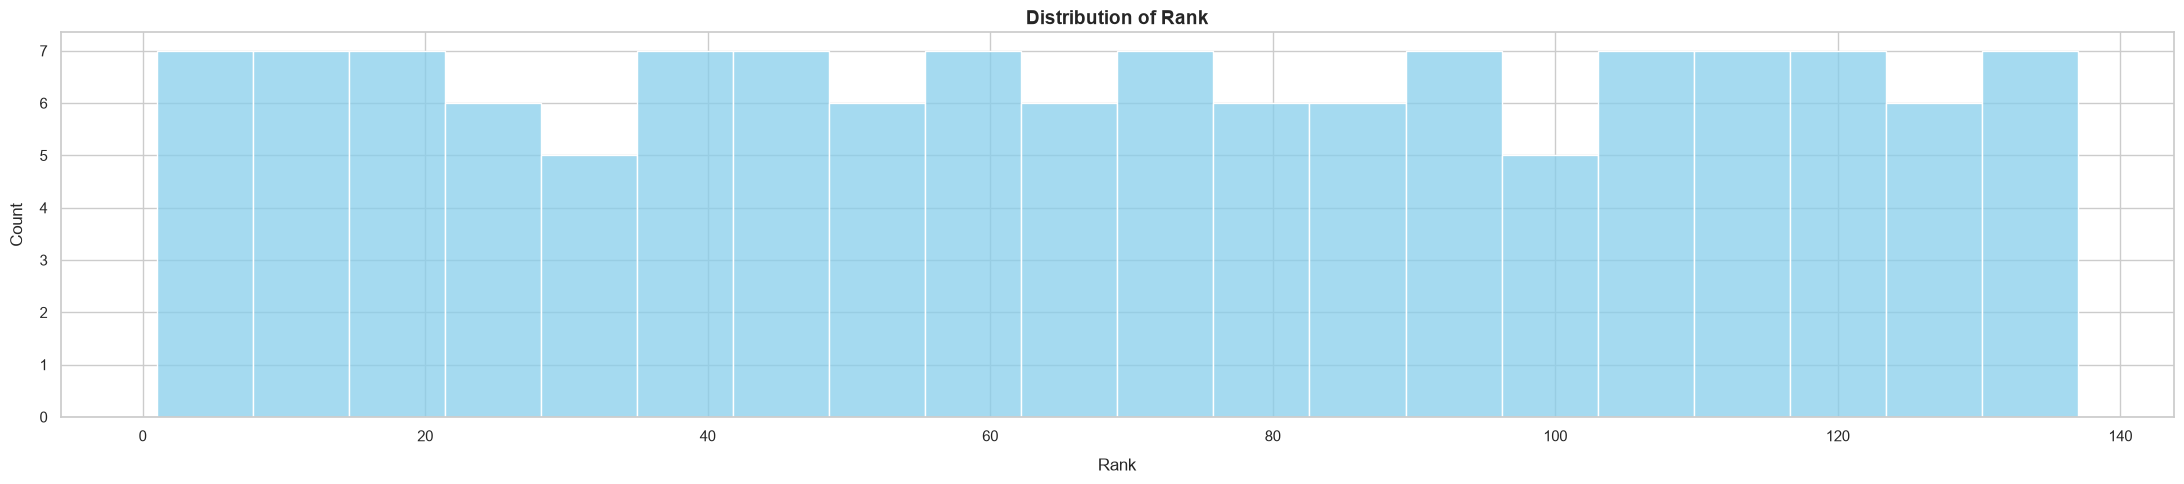

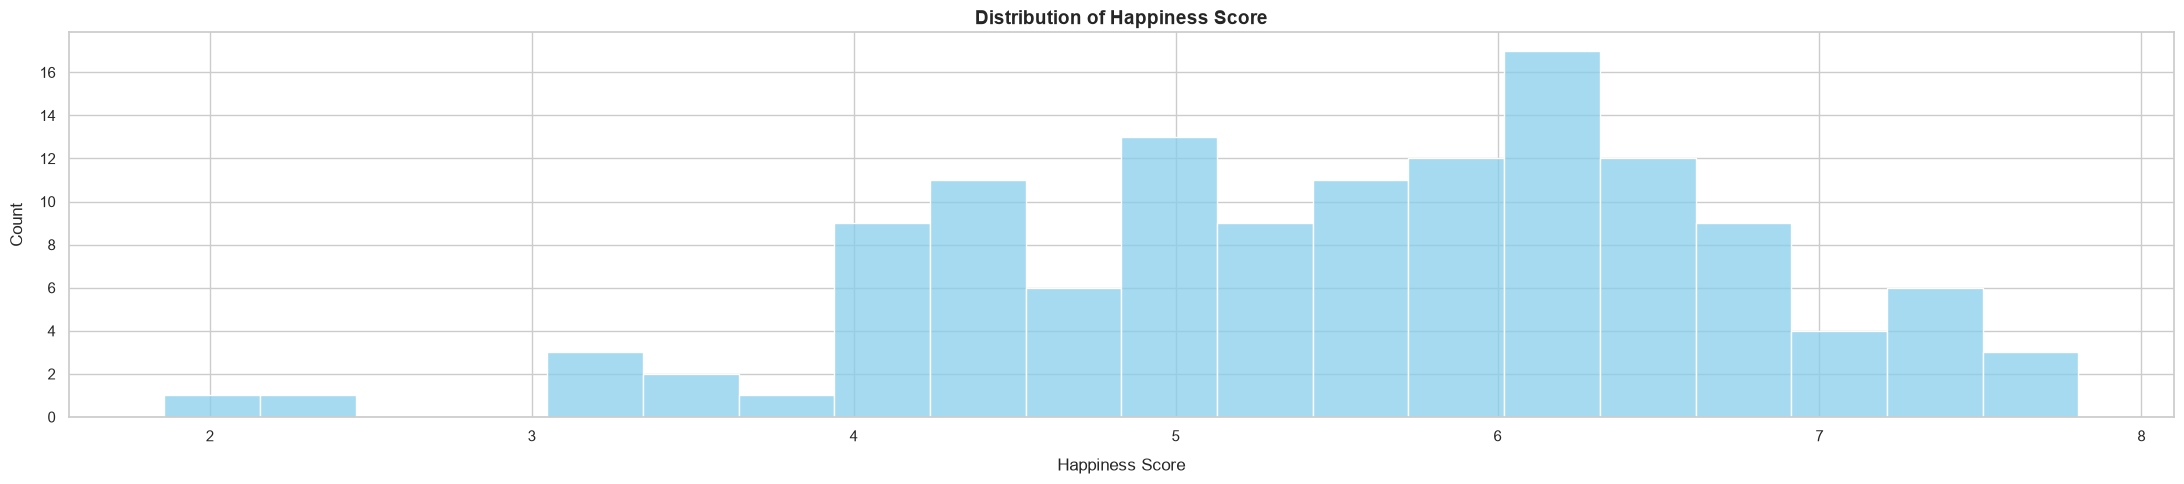

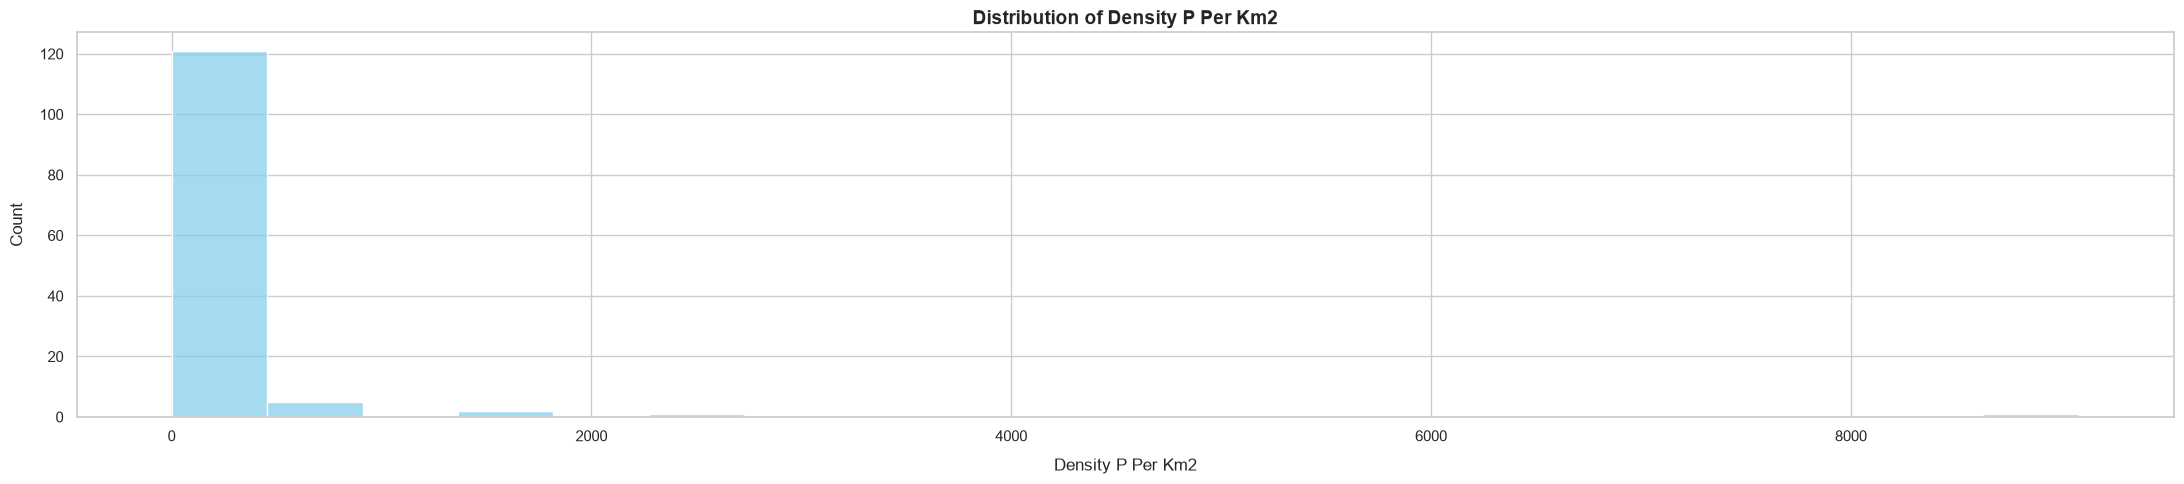

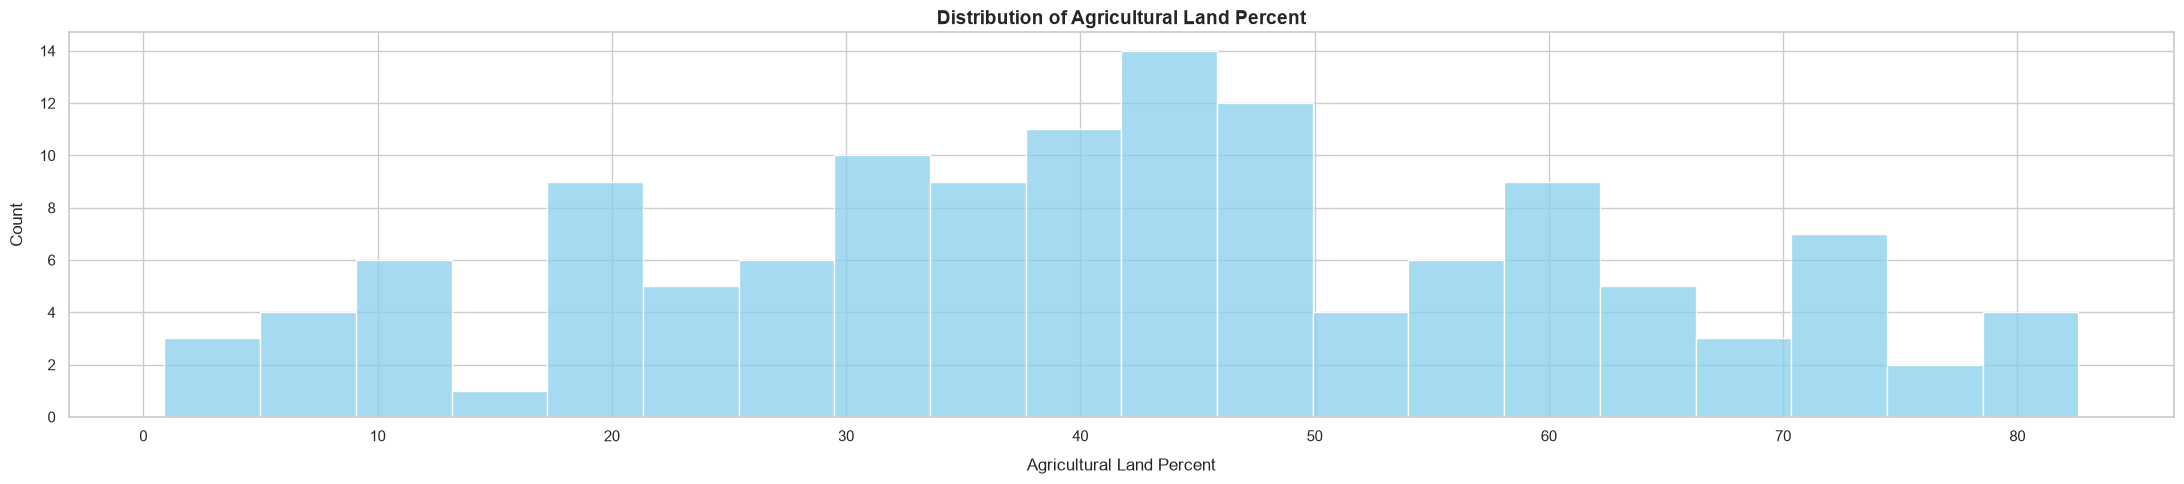

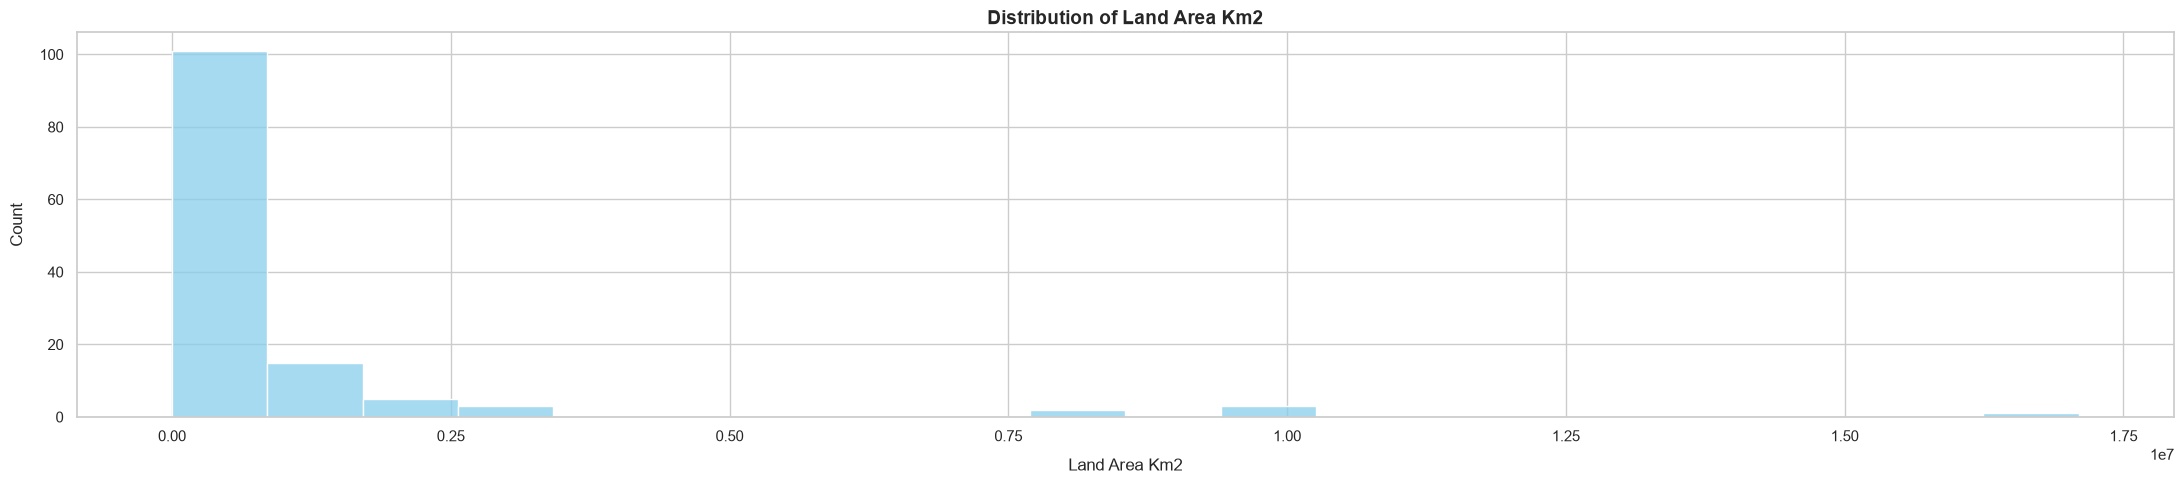

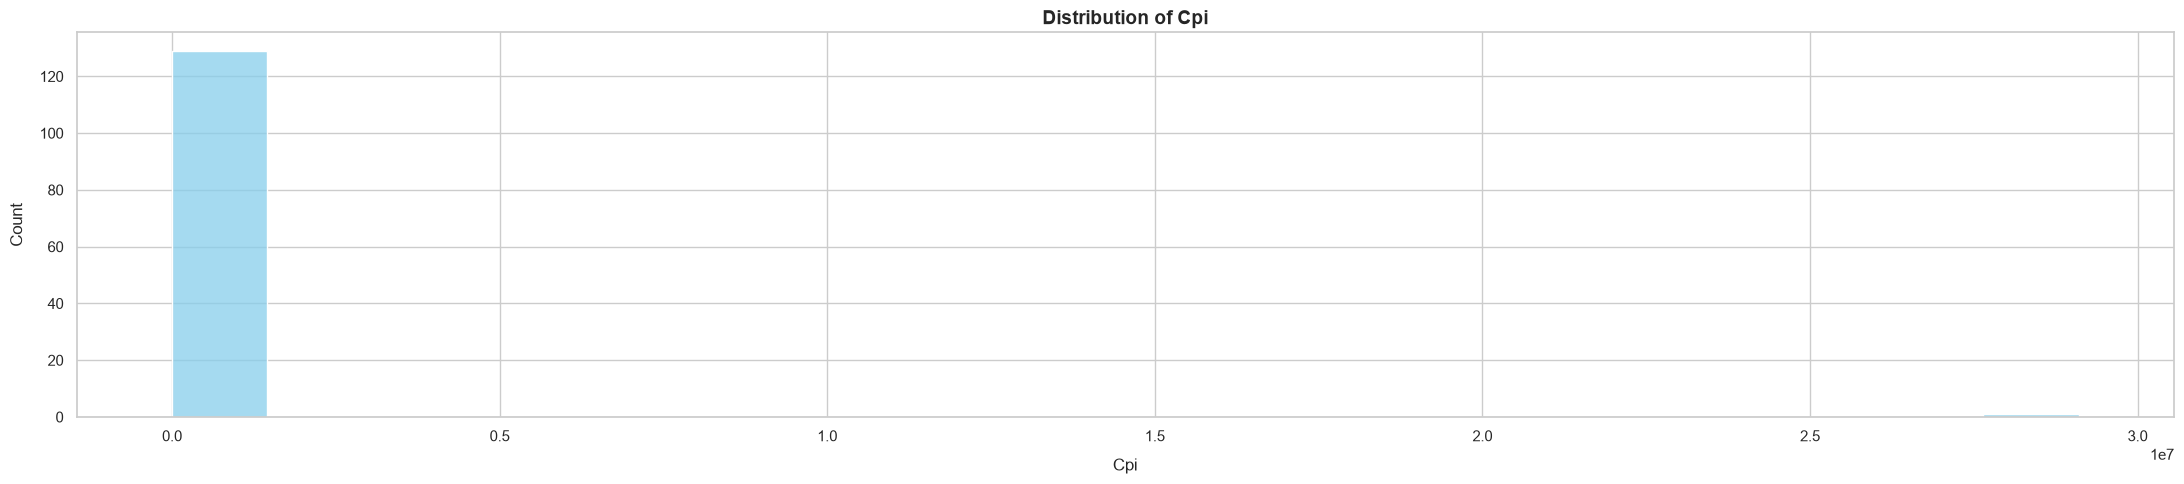

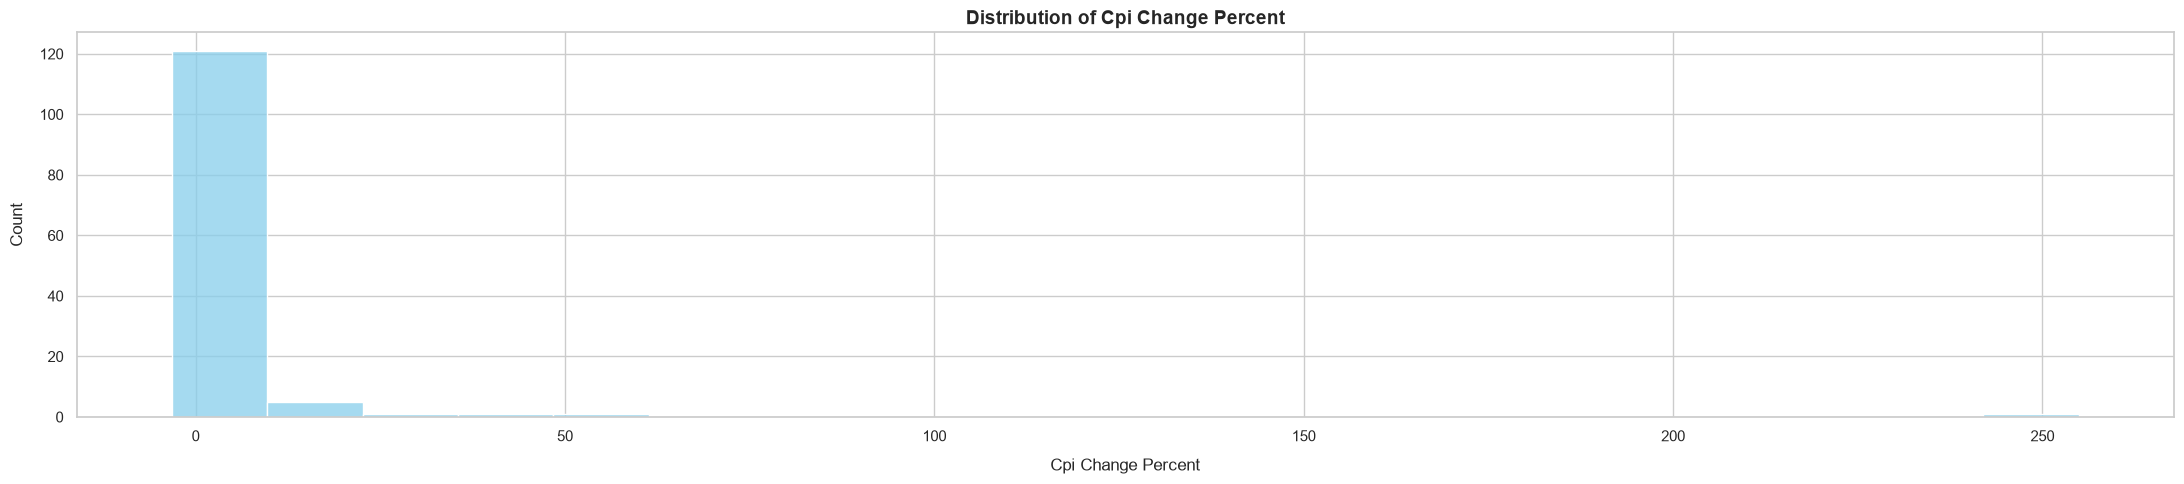

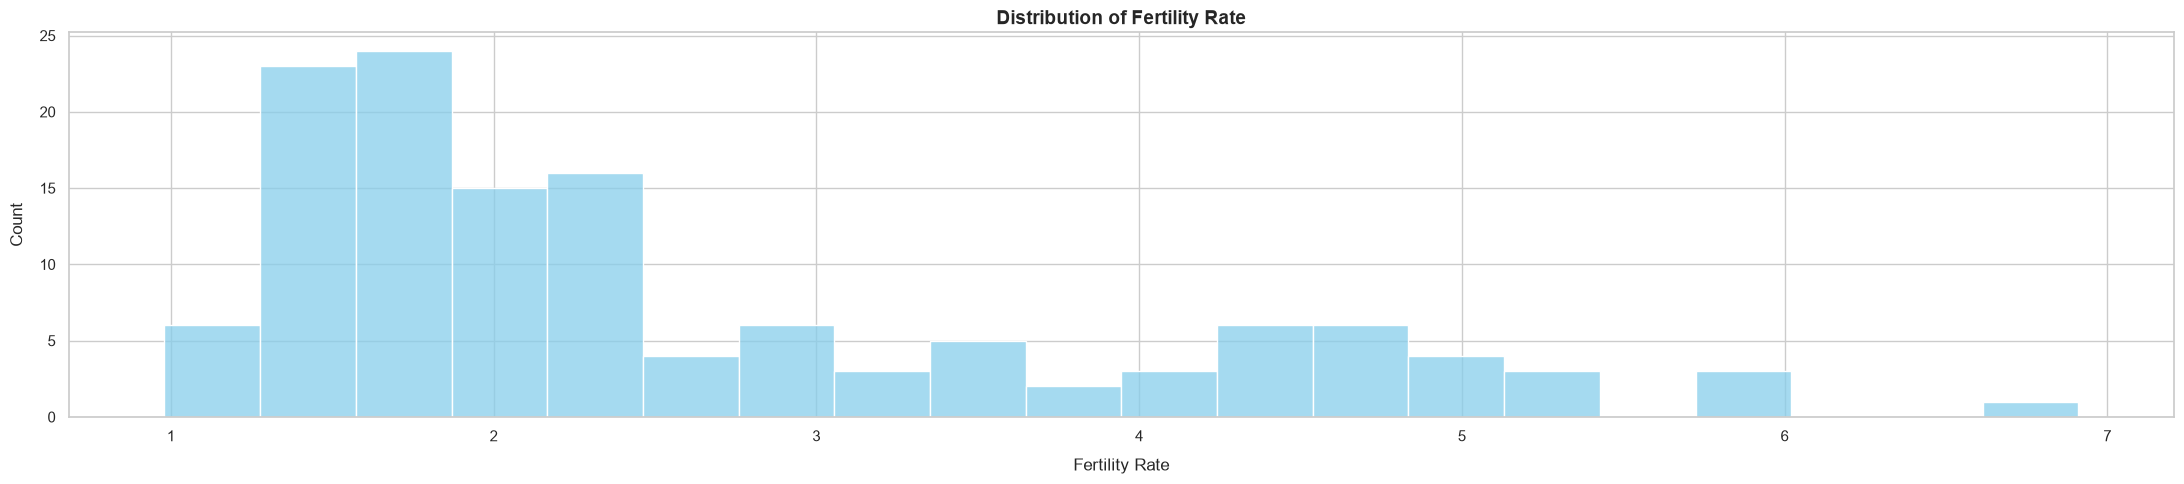

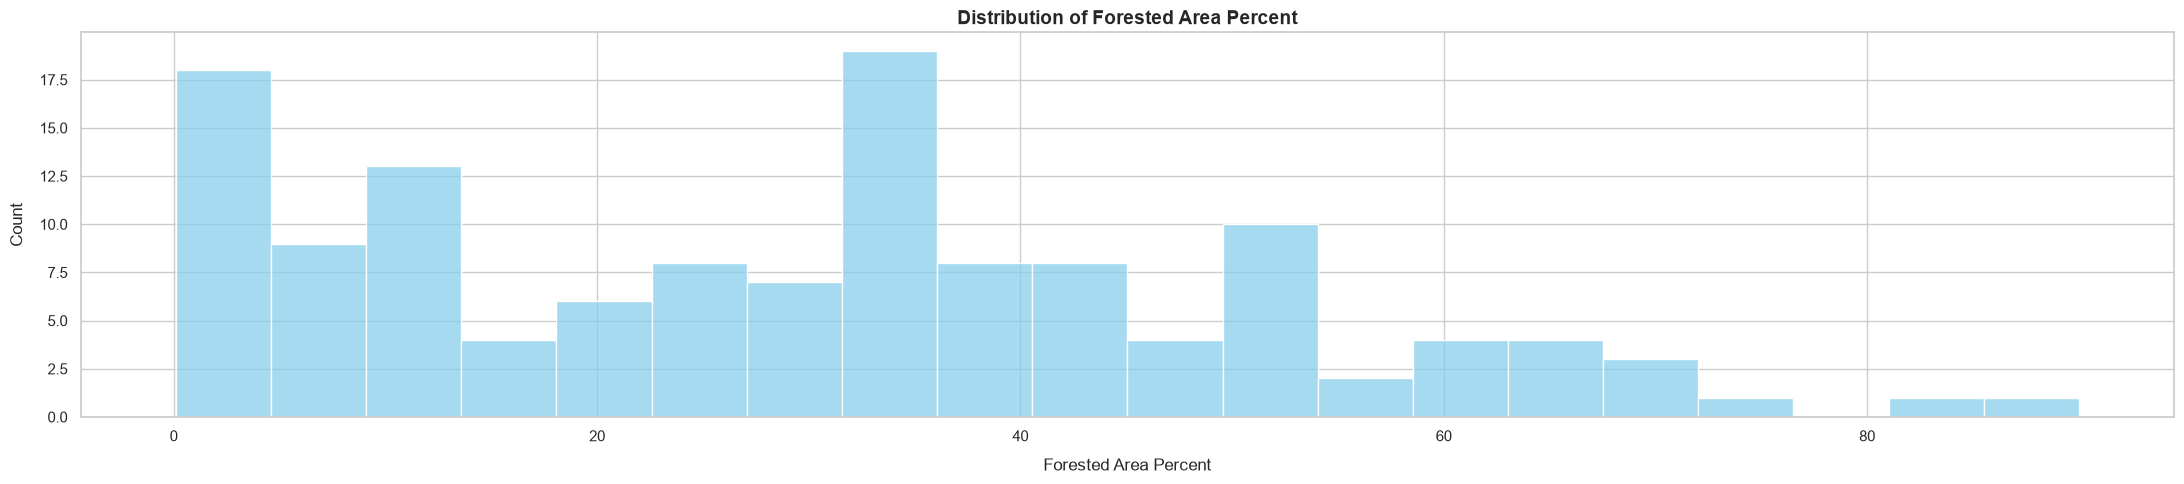

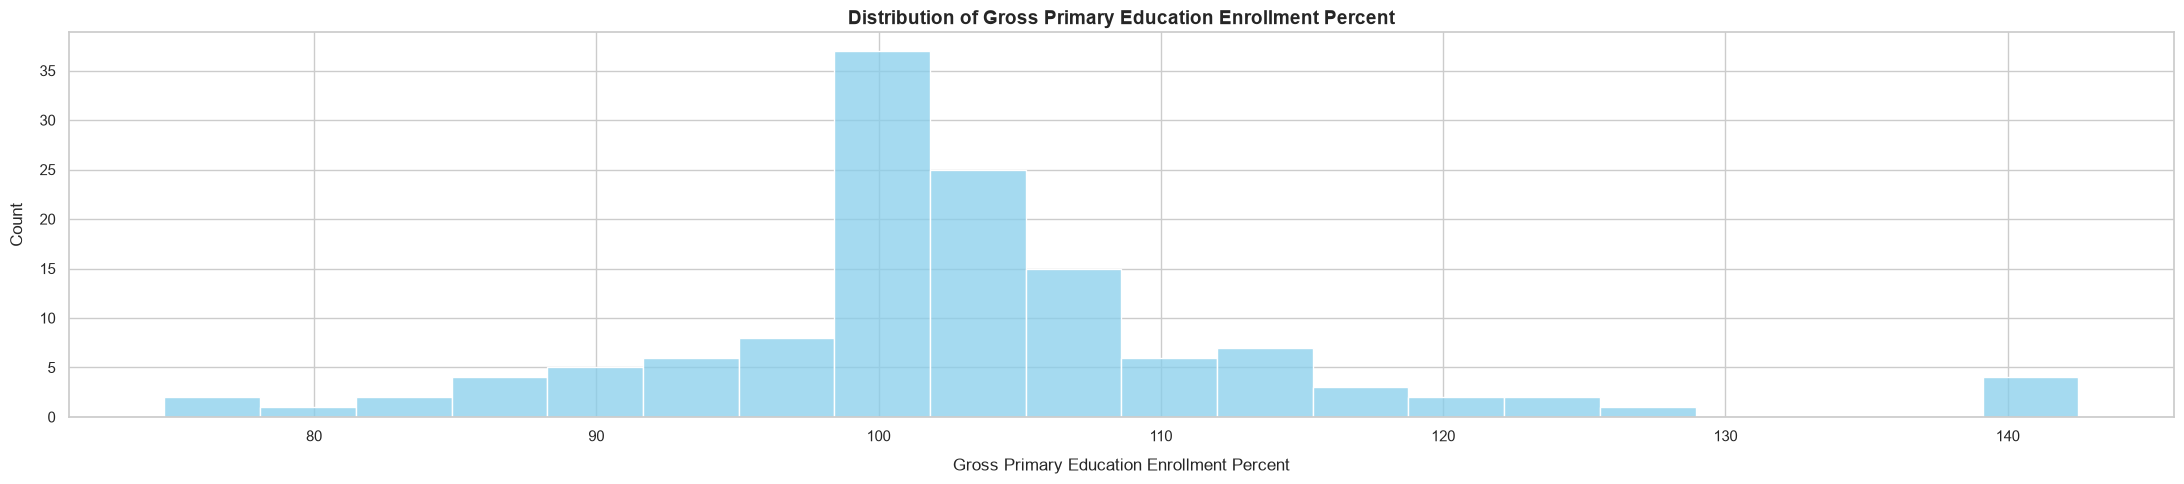

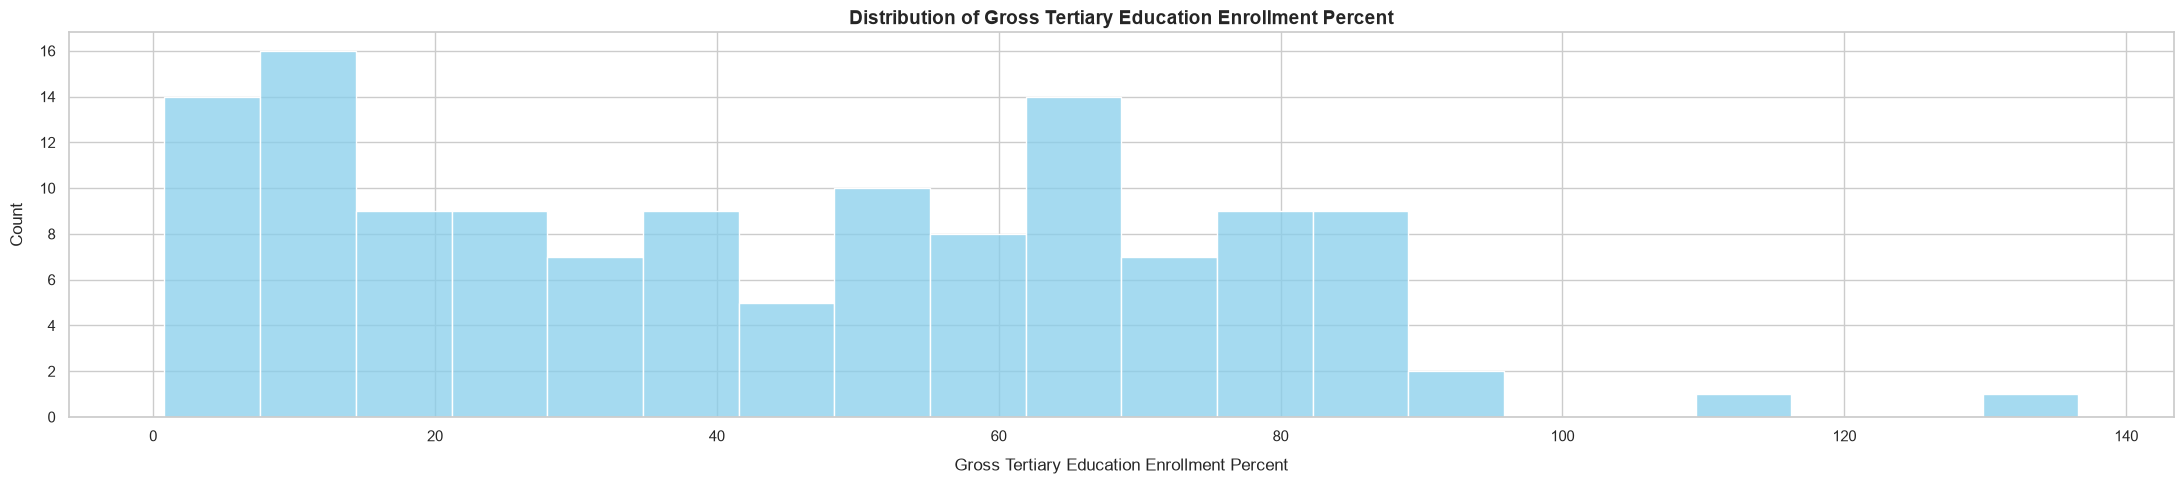

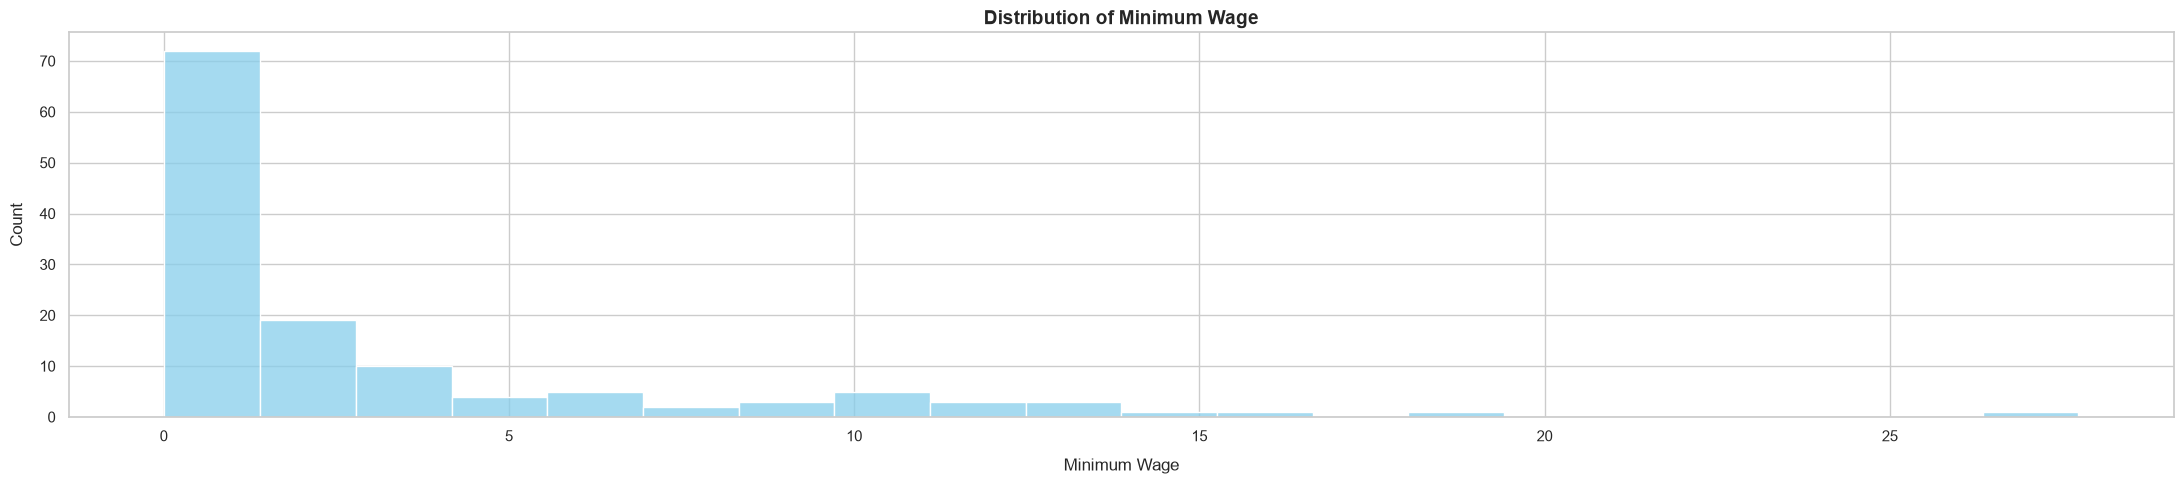

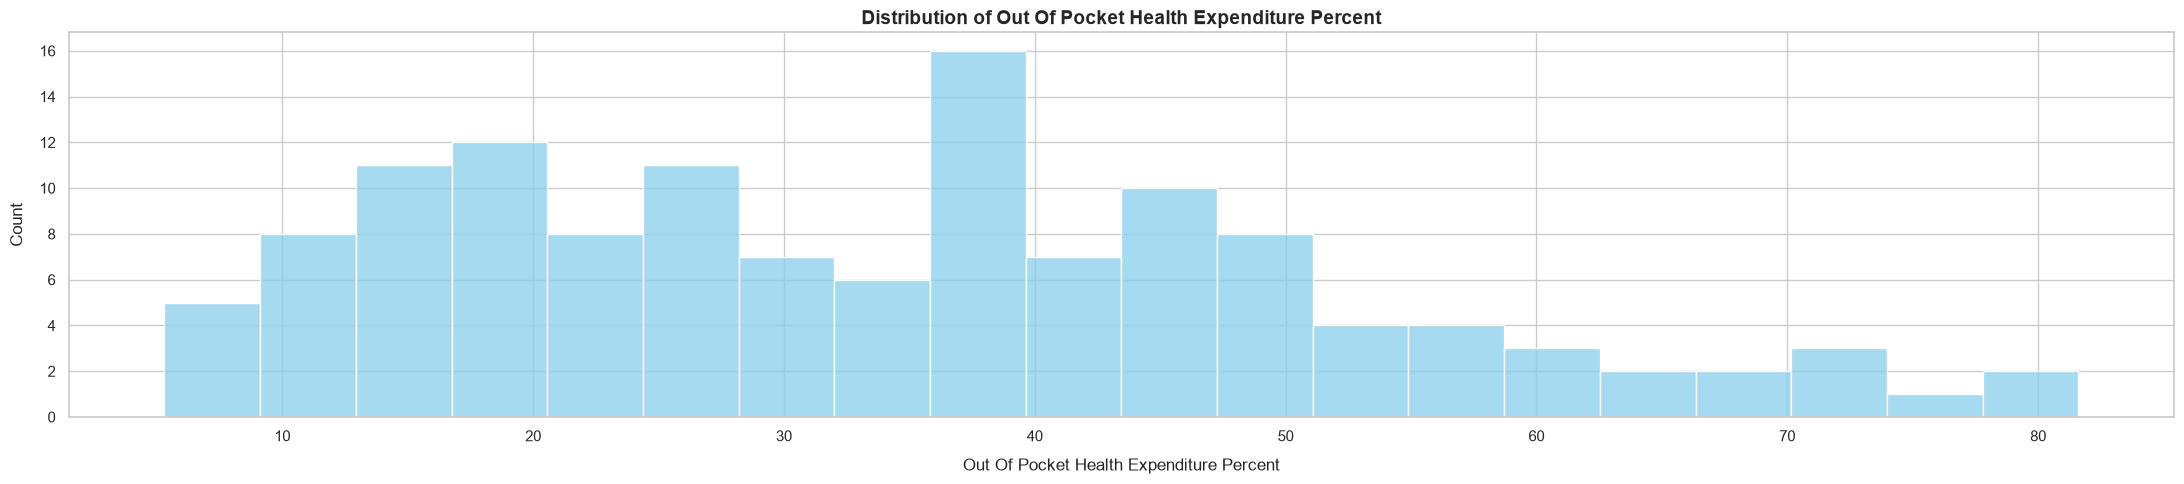

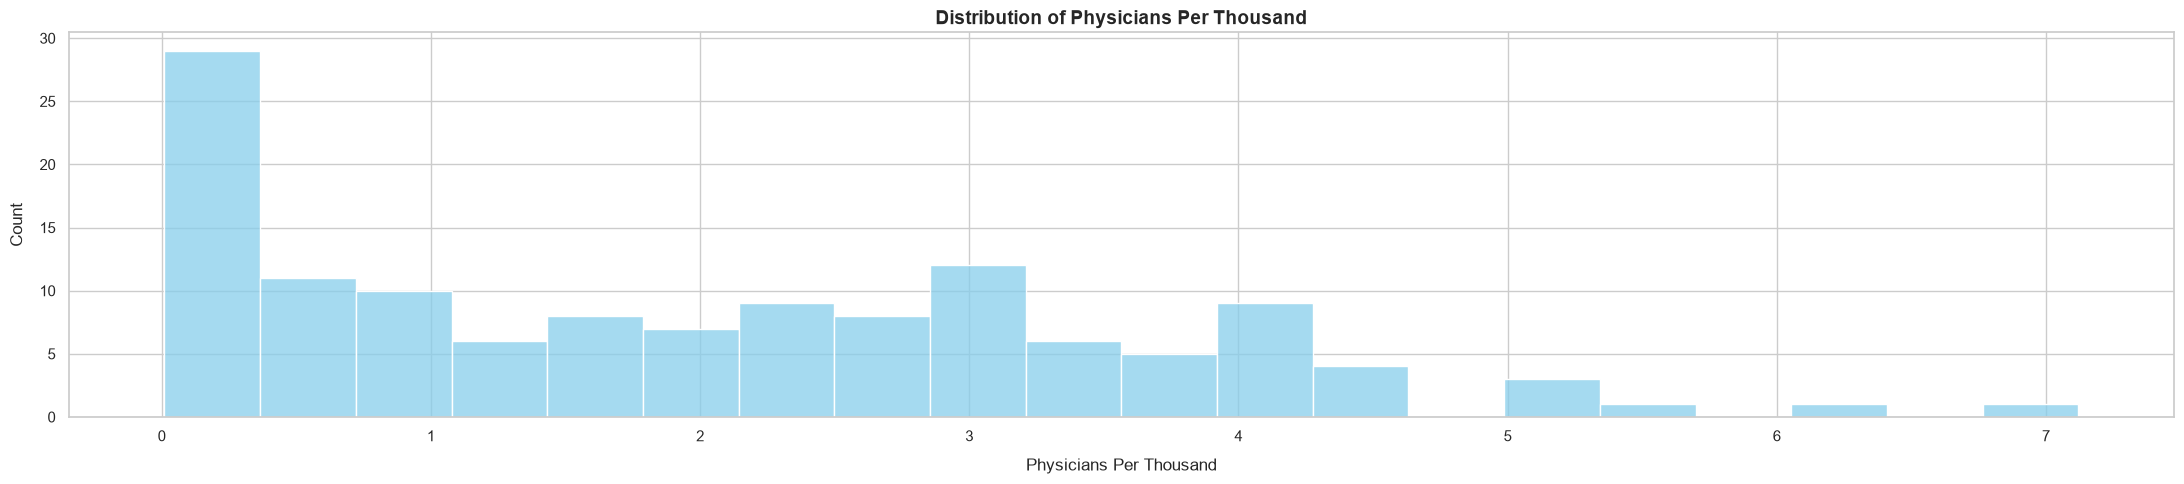

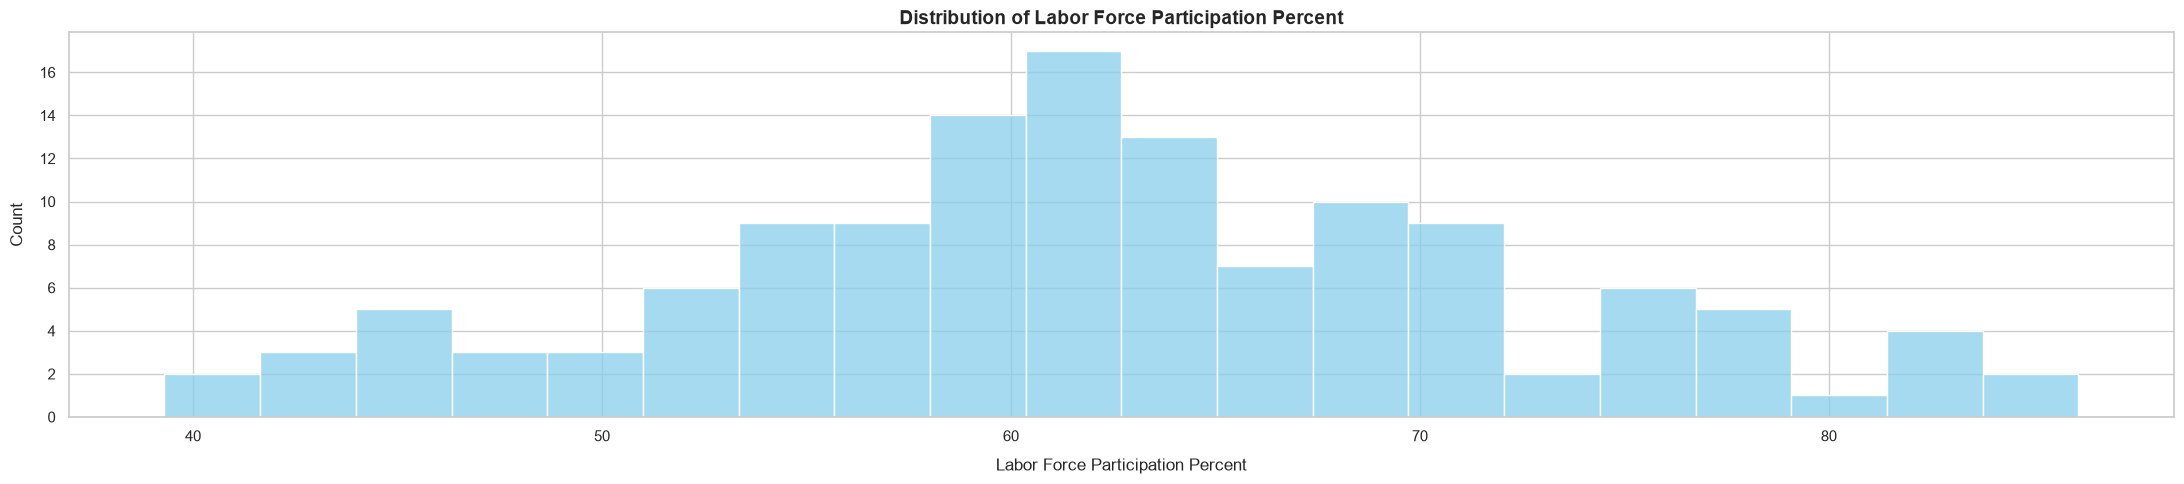

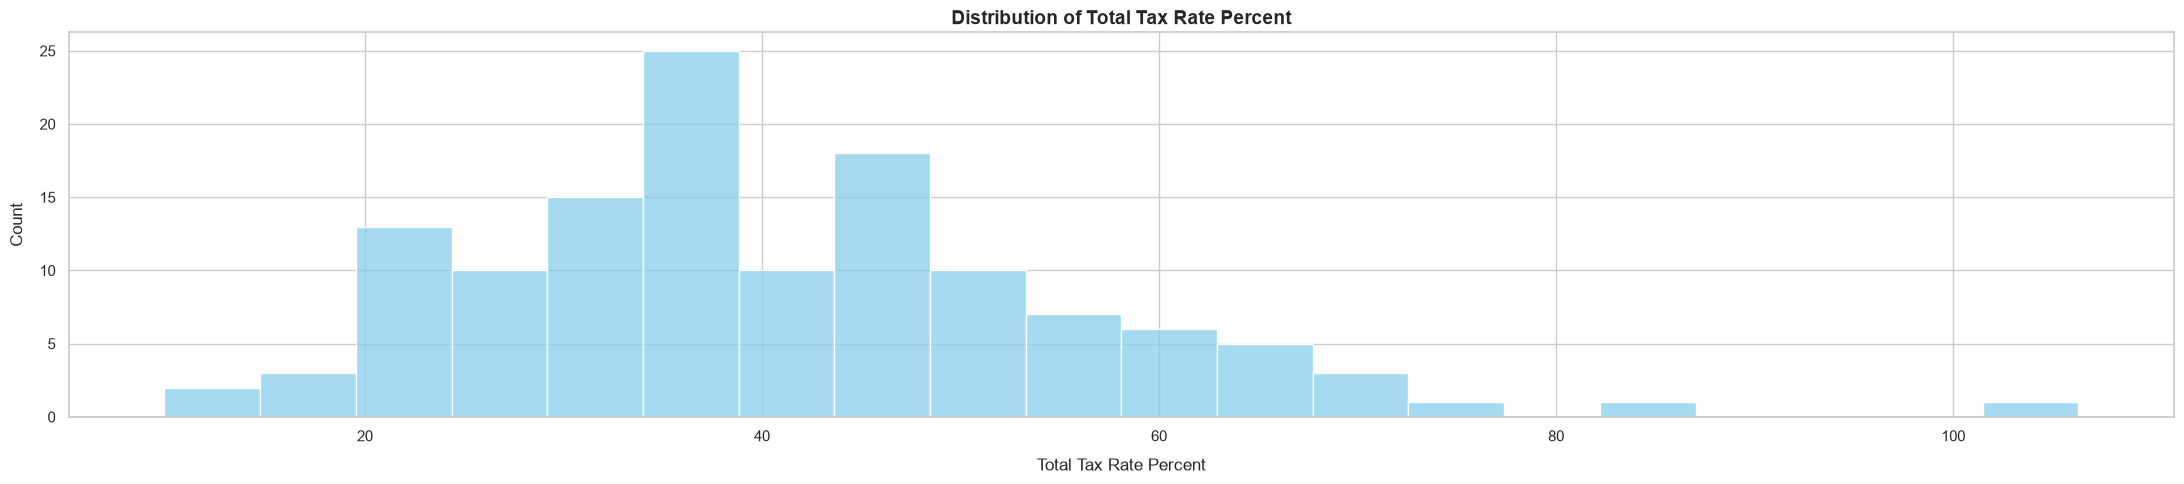

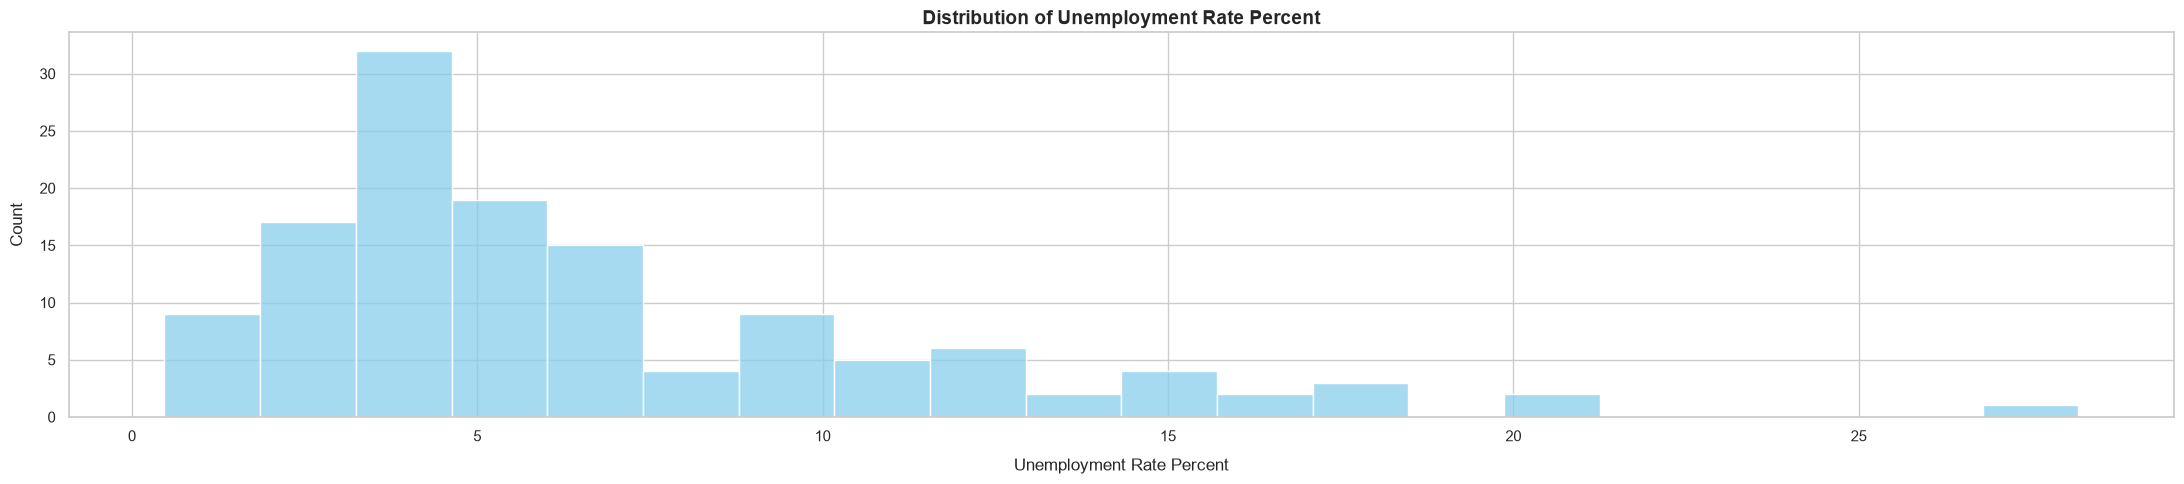

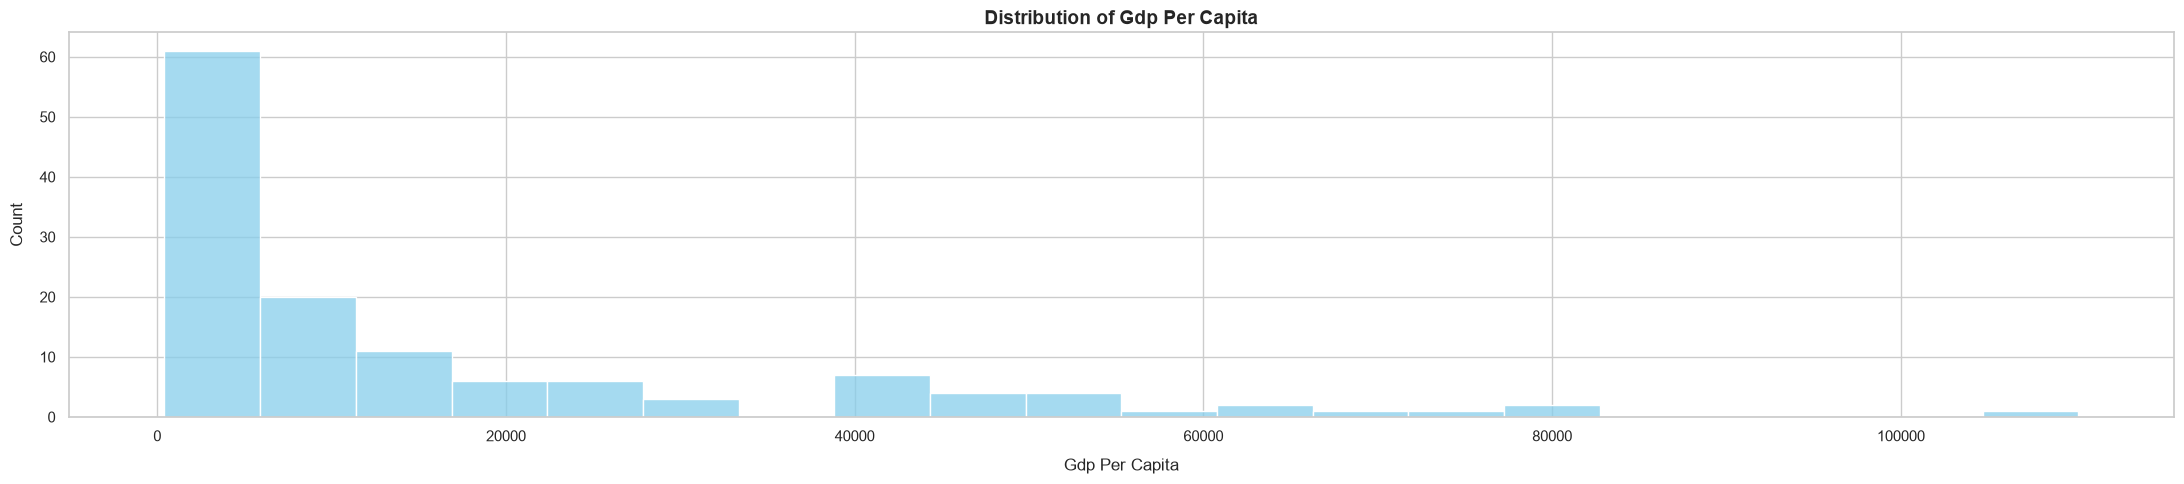

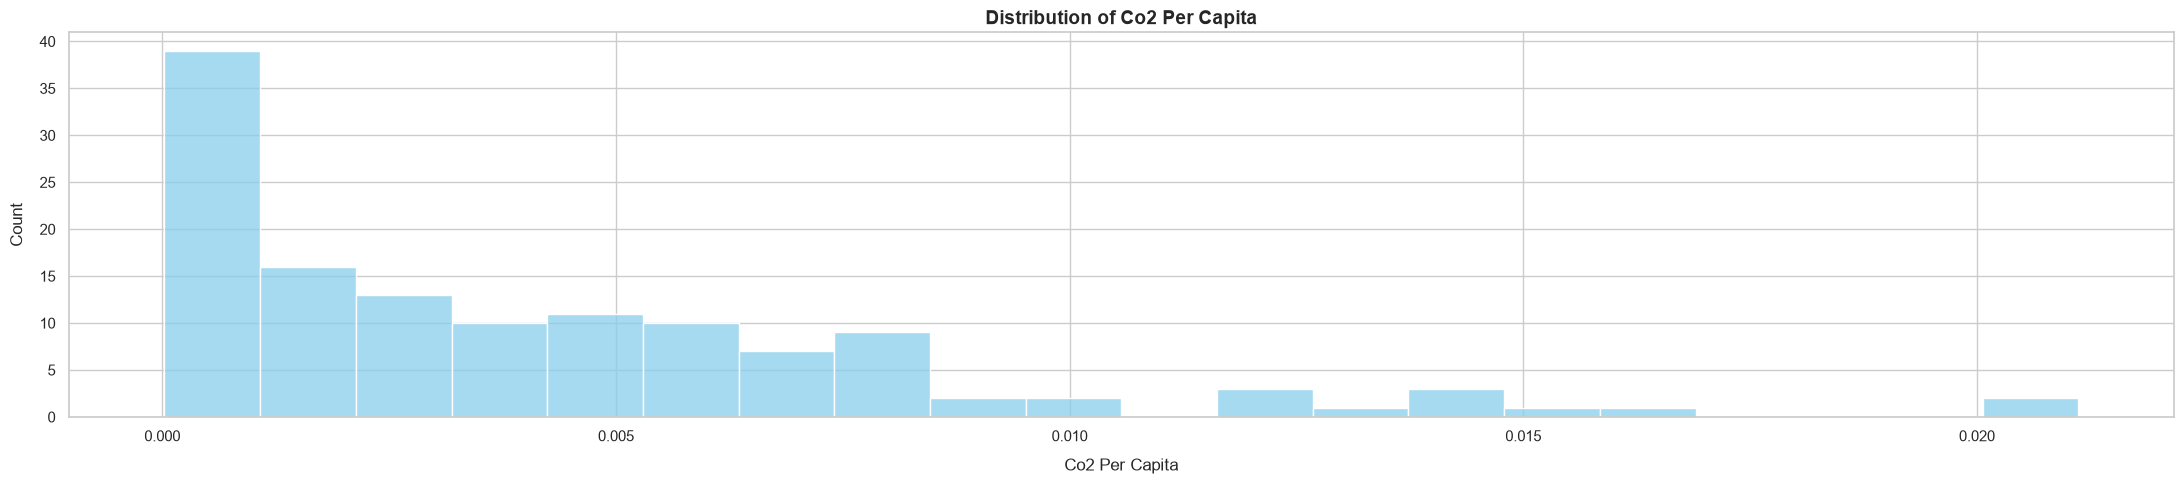

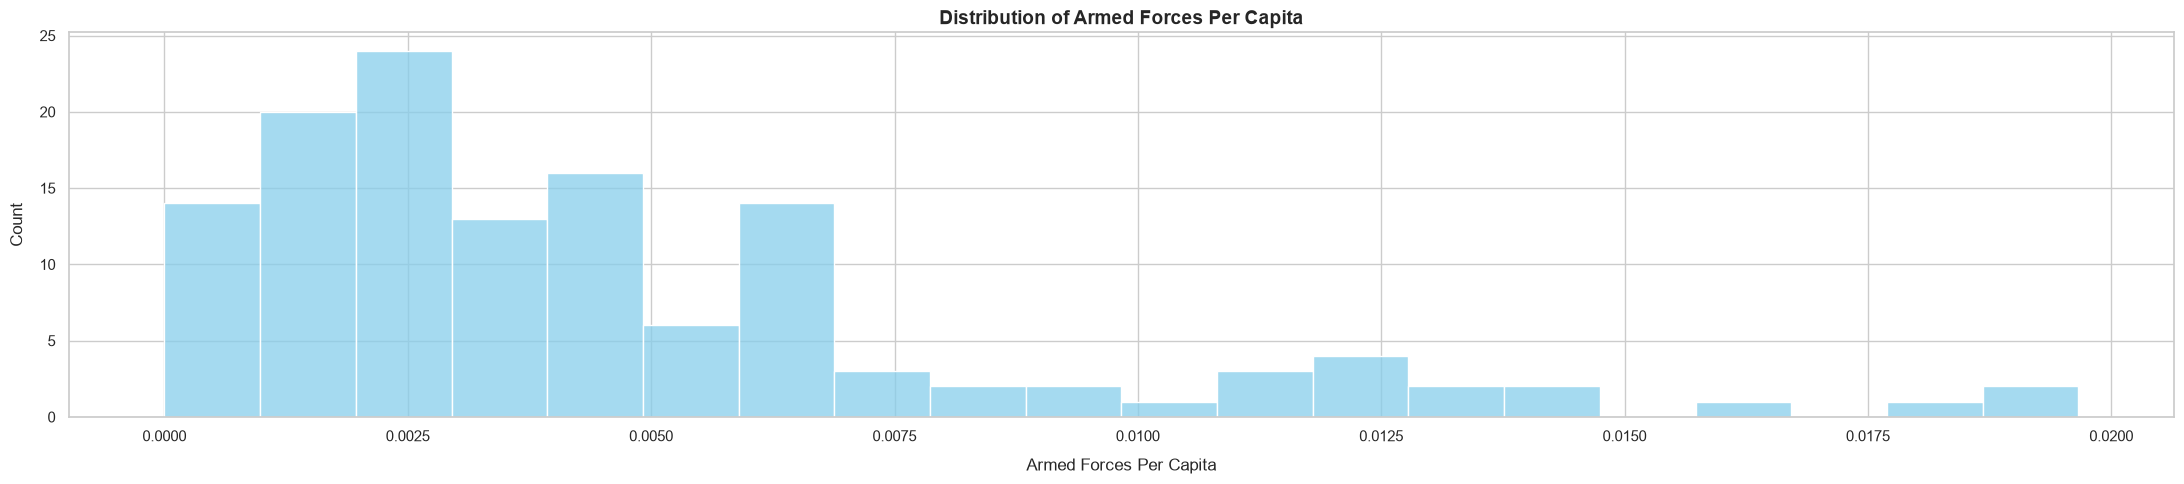

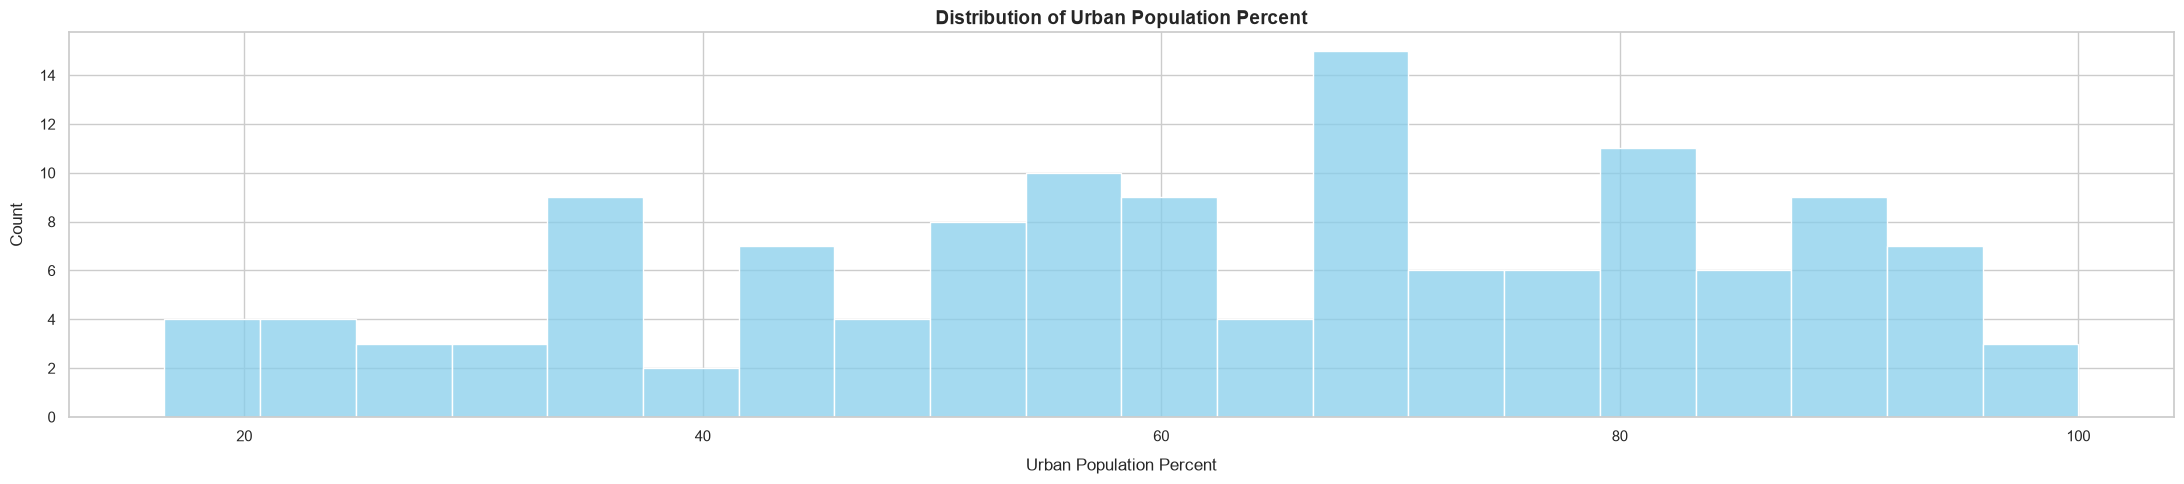

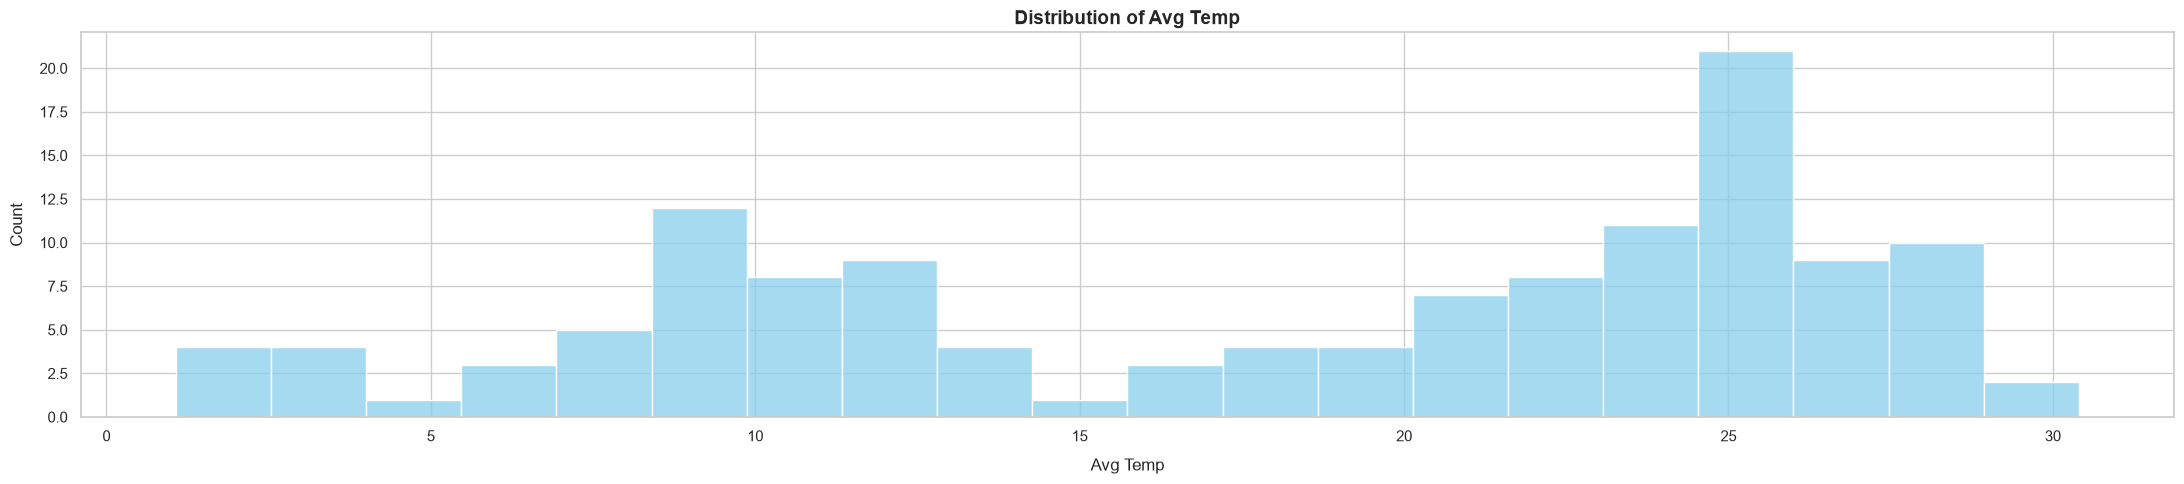

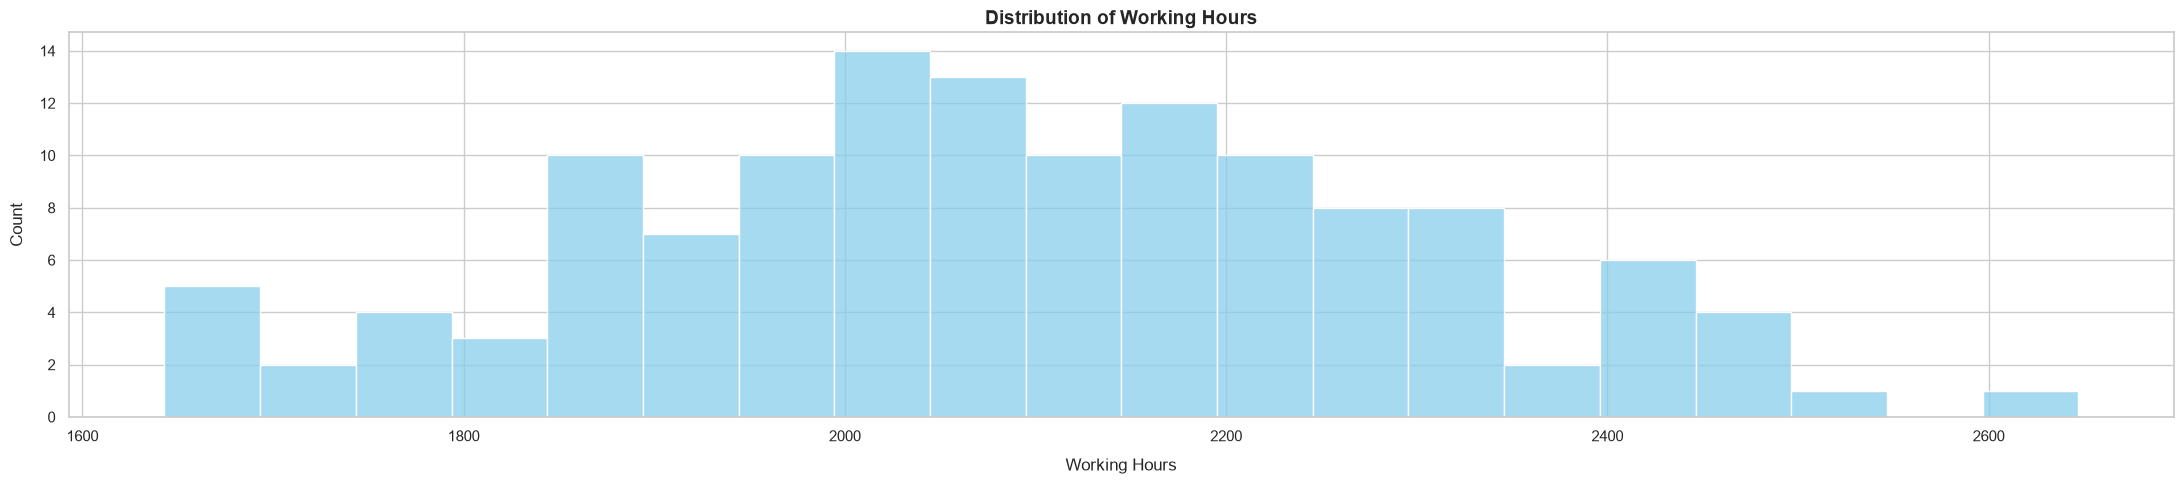

In [40]:
for col in num_cols:
    plt.figure(figsize=(22, 5))
    sns.histplot(data=df, x=col, bins=20, color='skyblue', edgecolor='white')
    plt.title(f'Distribution of {col.replace("_", " ").title()}', fontsize=14, fontweight='bold')
    plt.xlabel(col.replace('_', ' ').title(), fontsize=12, labelpad=10)
    plt.ylabel('Count', fontsize=12, labelpad=10)
    plt.xticks(fontsize=11)
    plt.yticks(fontsize=11)
    plt.tight_layout()
    plt.show()

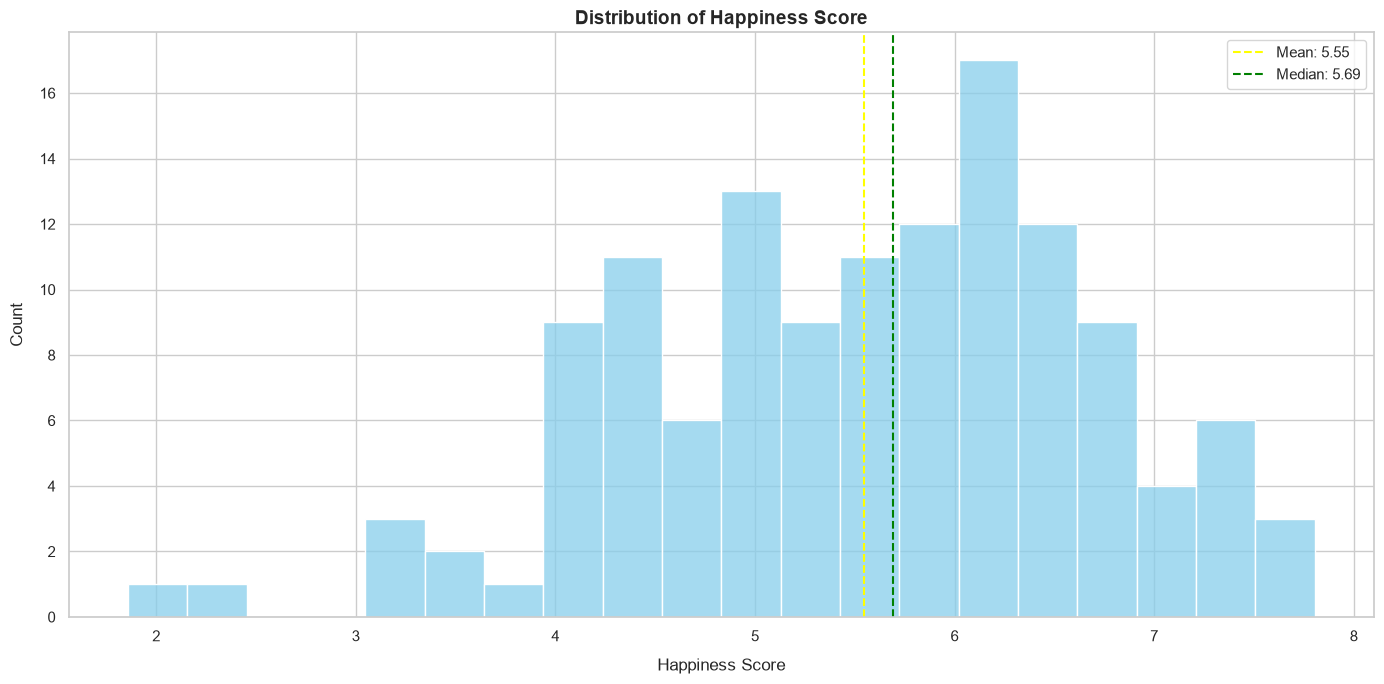

In [41]:
# Focus on the target variable: happiness_score
plt.figure(figsize=(14, 7))
sns.histplot(df['happiness_score'], bins=20, color='skyblue', edgecolor='white')
plt.axvline(df['happiness_score'].mean(), color='yellow', linestyle='--', label=f'Mean: {df["happiness_score"].mean():.2f}')
plt.axvline(df['happiness_score'].median(), color='green', linestyle='--', label=f'Median: {df["happiness_score"].median():.2f}')
plt.title('Distribution of Happiness Score', fontsize=14, fontweight='bold')
plt.xlabel('Happiness Score', fontsize=12, labelpad=10)
plt.ylabel('Count', fontsize=12, labelpad=10)
plt.xticks(fontsize=11)
plt.yticks(fontsize=11)
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

The chart shows that happiness scores across world countries follow a roughly normal distribution, 
ranging from 1.86 to 7.80. The mean and median are both close to 5.5,
 indicating a balanced distribution with most countries clustered in the middle.

 A small number of countries appear at the extremes highly happy nations like Finland at the top, 
 and struggling nations like Afghanistan at the bottom.

14  Categorical Analysis

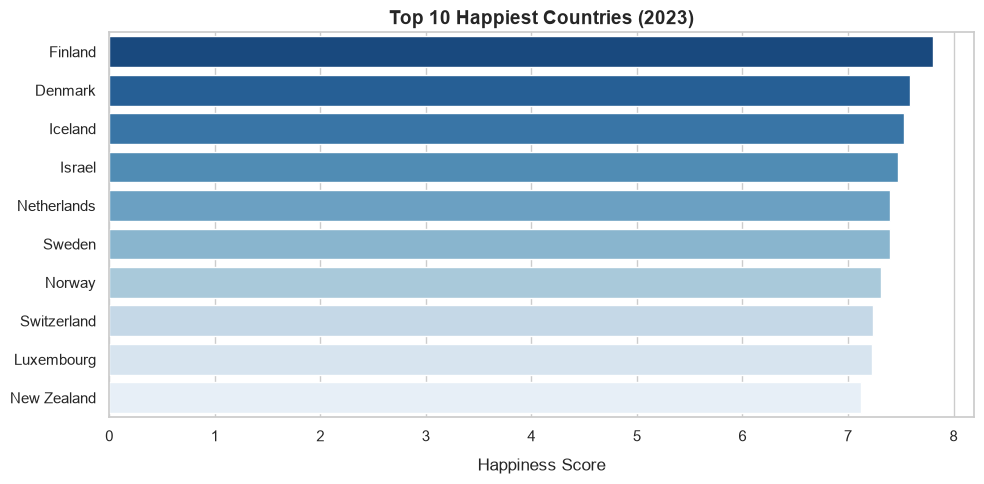

In [49]:
# Top 10 happiest countries

top10 = df.nsmallest(10, 'rank')[['country', 'happiness_score']]

plt.figure(figsize=(10, 5))
sns.barplot(data=top10, x='happiness_score', y='country', hue='country', palette='Blues_r', legend=False)
plt.title('Top 10 Happiest Countries (2023)', fontsize=14, fontweight='bold')
plt.xlabel('Happiness Score', fontsize=12, labelpad=10)
plt.ylabel('', fontsize=12)
plt.xticks(fontsize=11)
plt.yticks(fontsize=11)
plt.tight_layout()
plt.show()

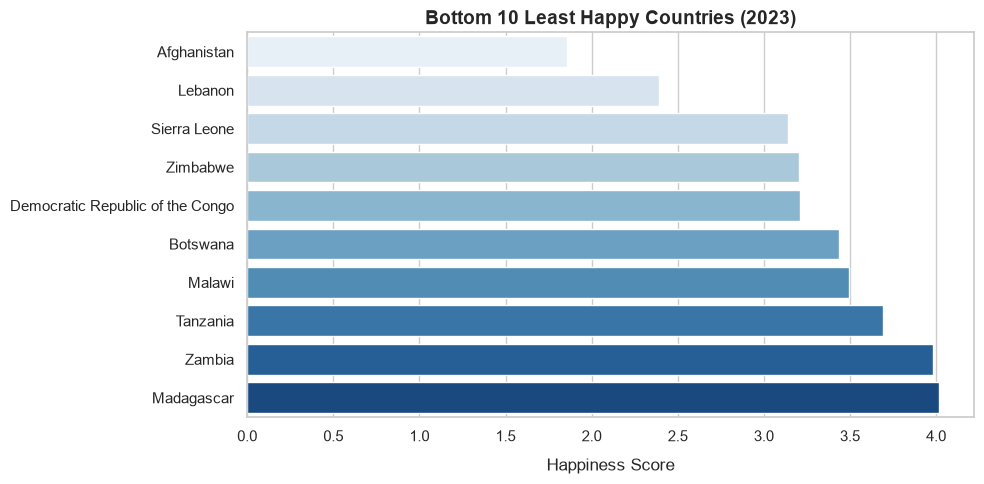

In [50]:
# Bottom 10 least happy countries
bottom10 = df.nlargest(10, 'rank')[['country', 'happiness_score']]

plt.figure(figsize=(10, 5))
sns.barplot(data=bottom10, x='happiness_score', y='country', hue='country', palette='Blues', legend=False)
plt.title('Bottom 10 Least Happy Countries (2023)', fontsize=14, fontweight='bold')
plt.xlabel('Happiness Score', fontsize=12, labelpad=10)
plt.ylabel('', fontsize=12)
plt.xticks(fontsize=11)
plt.yticks(fontsize=11)
plt.tight_layout()
plt.show()

## Step 15 — Detect Outliers

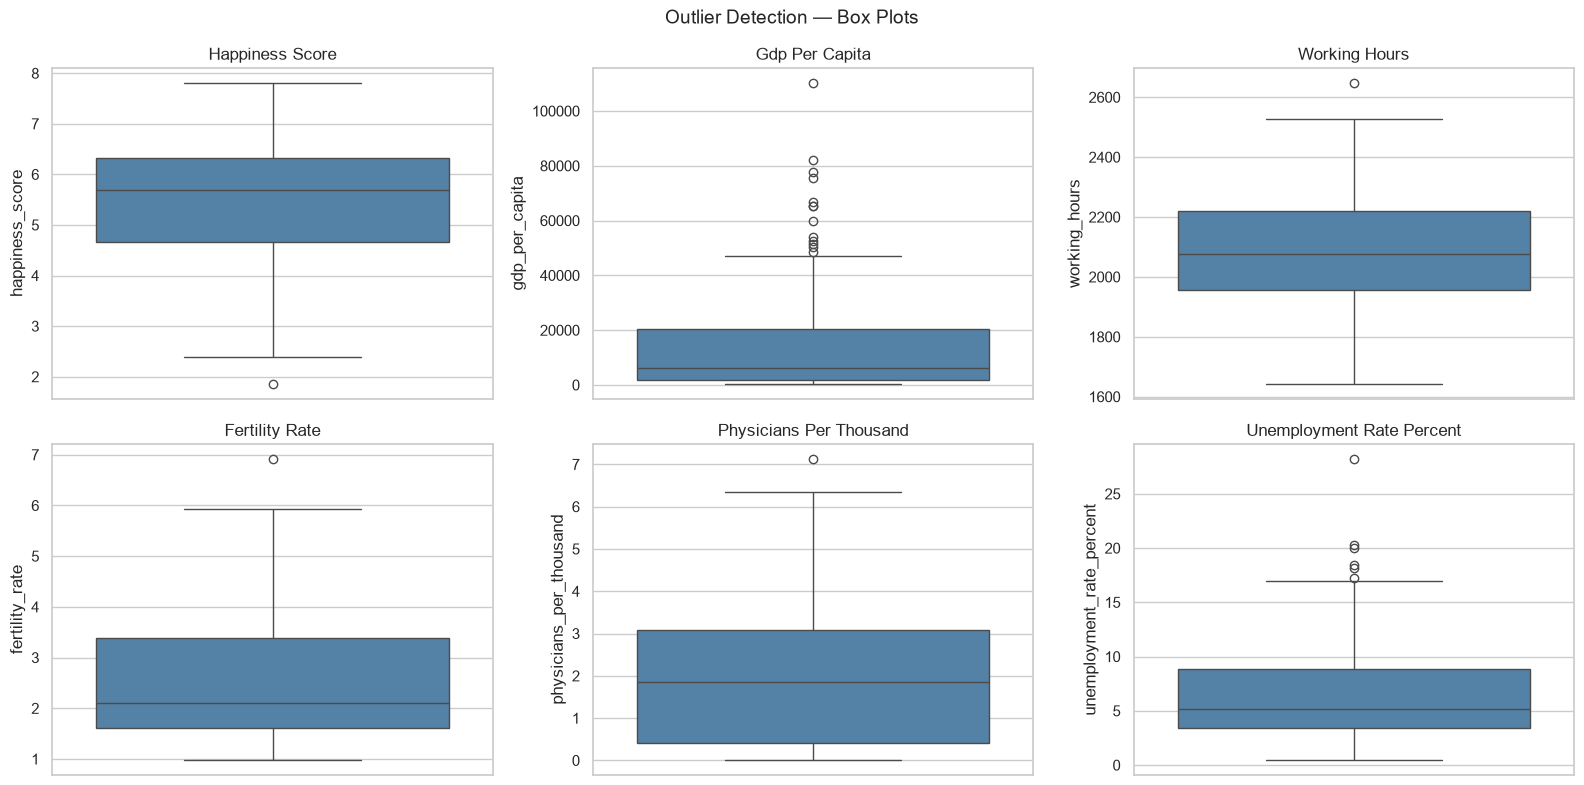

In [51]:
# Box plots for key variables
key_vars = ['happiness_score', 'gdp_per_capita', 'working_hours',
            'fertility_rate', 'physicians_per_thousand', 'unemployment_rate_percent']

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

for i, col in enumerate(key_vars):
    sns.boxplot(y=df[col], ax=axes[i], color='steelblue')
    axes[i].set_title(col.replace('_', ' ').title())

plt.suptitle('Outlier Detection — Box Plots', fontsize=14)
plt.tight_layout()
plt.show()

In [53]:
# IQR method to identify outliers in happiness_score
for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    
    if len(outliers) > 0:
        print(f'\n📌 {col.replace("_", " ").title()} — {len(outliers)} outlier(s):')
        print(outliers[['country', col]].to_string(index=False))


📌 Happiness Score — 1 outlier(s):
    country  happiness_score
Afghanistan            1.859

📌 Density P Per Km2 — 14 outlier(s):
    country  density_p_per_km2
    Bahrain             2450.5
 Bangladesh             1370.0
    Belgium              383.0
      India              464.0
     Israel              400.0
      Japan              347.0
    Lebanon              667.0
      Malta             1620.4
  Mauritius              626.0
Netherlands              508.0
Philippines              368.0
  Singapore             9084.8
South Korea              527.0
  Sri Lanka              341.0

📌 Land Area Km2 — 14 outlier(s):
                         country  land_area_km2
                         Algeria        2381741
                       Argentina        2780400
                       Australia        7741220
                          Brazil        8515770
                          Canada        9984670
                           China        9596960
Democratic Republic of the Congo  

## Step 16 — Correlation Analysis

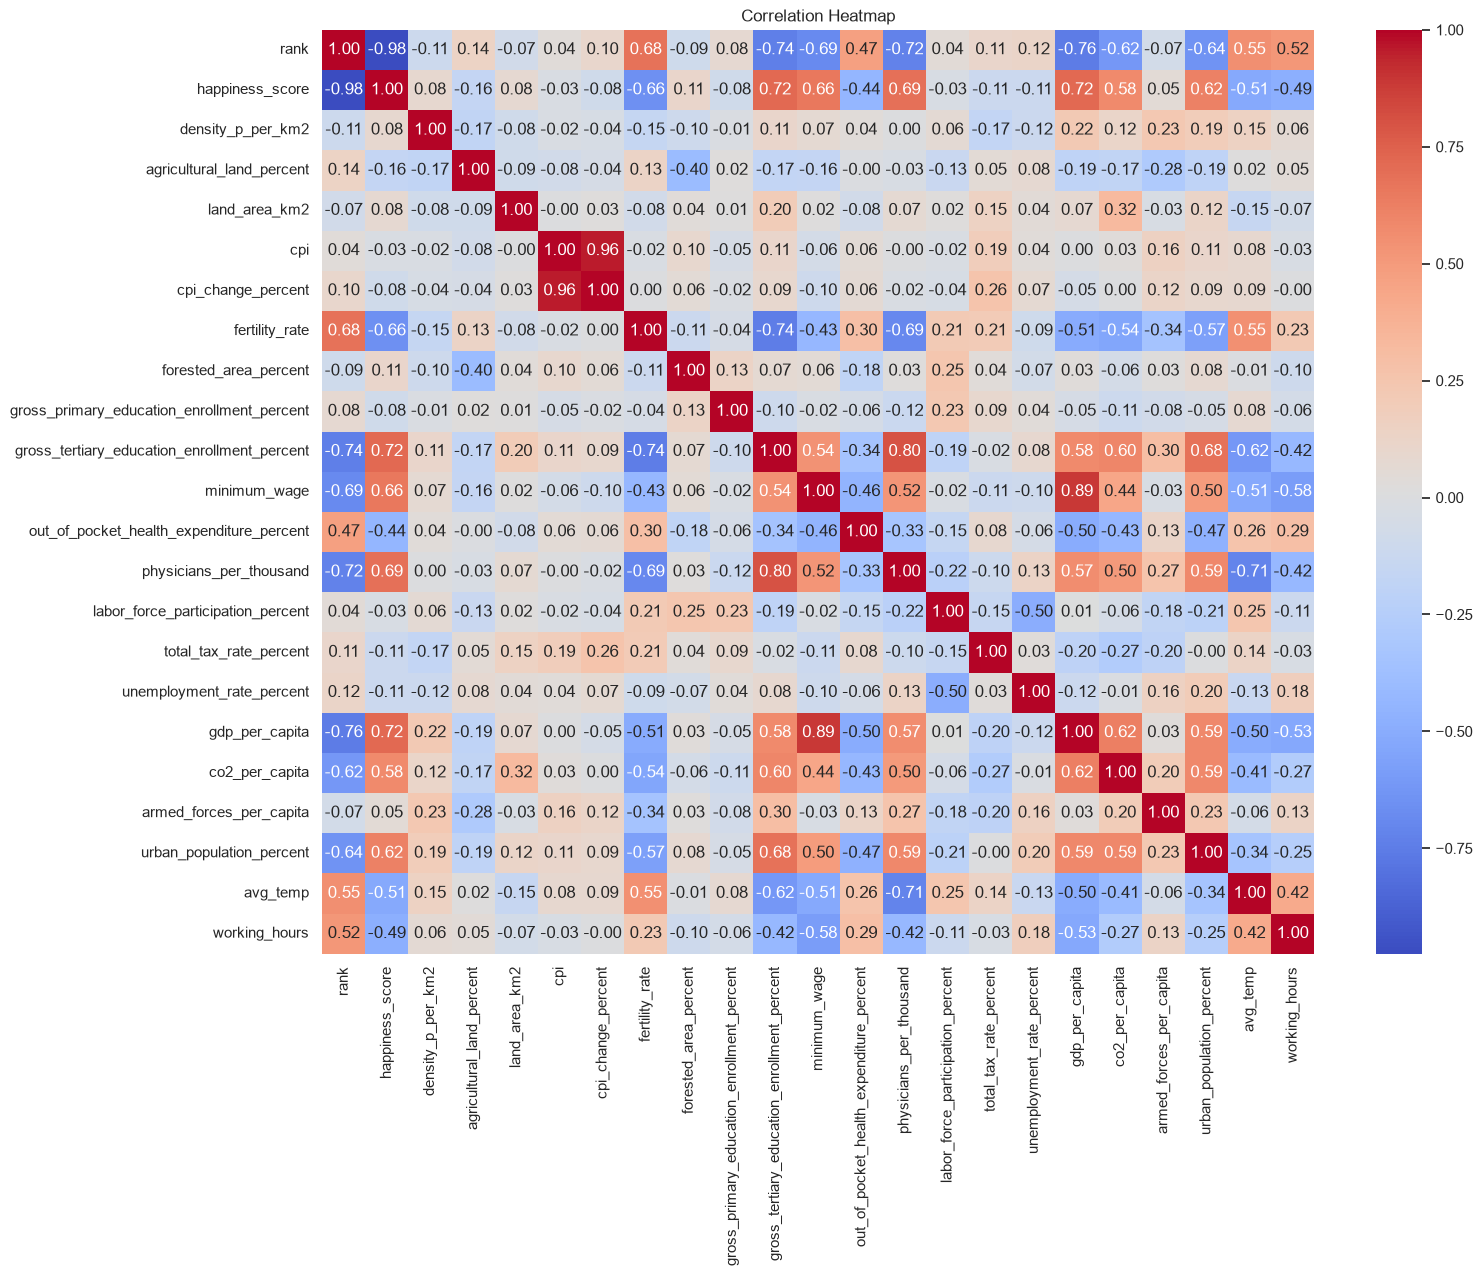

In [56]:
# A heatmap shows how strongly numerical columns relate to each other.
# Values close to 1 or -1 mean a strong relationship.
plt.figure(figsize=(16, 12))
numeric_cols = df.select_dtypes(include="number")
sns.heatmap(numeric_cols.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

## Step 17 — Feature vs Target (happiness_score)

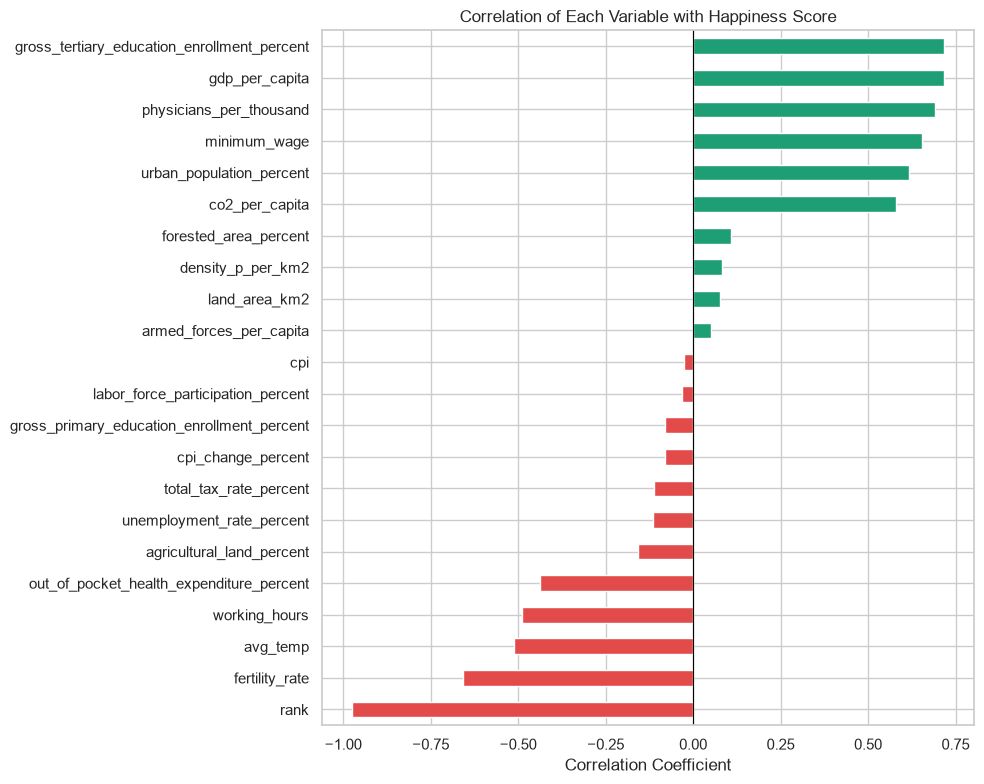

In [57]:
# Correlation with happiness_score ranked
corr_with_happiness = df[num_cols].corr()['happiness_score'].drop('happiness_score').sort_values()

plt.figure(figsize=(10, 8))
colors = ['#E24B4A' if x < 0 else '#1D9E75' for x in corr_with_happiness]
corr_with_happiness.plot(kind='barh', color=colors)
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Correlation of Each Variable with Happiness Score')
plt.xlabel('Correlation Coefficient')
plt.tight_layout()
plt.show()

In [ ]:
# Scatter plots: top 4 predictors vs happiness_score
top_predictors = ['gdp_per_capita', 'gross_tertiary_education_enrollment_percent',
                  'physicians_per_thousand', 'fertility_rate']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(top_predictors):
    sns.regplot(data=df, x=col, y='happiness_score', ax=axes[i],
                scatter_kws={'alpha': 0.6, 'color': 'steelblue'},
                line_kws={'color': 'red'})
    axes[i].set_title(f'{col.replace("_", " ").title()} vs Happiness Score')

plt.suptitle('Top Predictors vs Happiness Score', fontsize=14)
plt.tight_layout()
plt.show()

## Step 18 — Additional Visualizations

In [ ]:
# Temperature vs Happiness
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='avg_temp', y='happiness_score',
                hue='happiness_score', palette='RdYlGn', size='gdp_per_capita',
                sizes=(20, 300), alpha=0.8, legend=False)

# Annotate some interesting countries
for _, row in df[df['country'].isin(['Finland','Afghanistan','United Arab Emirates','Lebanon','Saudi Arabia'])].iterrows():
    plt.annotate(row['country'], (row['avg_temp'], row['happiness_score']),
                 fontsize=8, ha='left', xytext=(5, 2), textcoords='offset points')

plt.title('Average Temperature vs Happiness Score\n(bubble size = GDP per capita)')
plt.xlabel('Average Temperature (°C)')
plt.ylabel('Happiness Score')
plt.show()

In [ ]:
# Working hours vs Happiness
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='working_hours', y='happiness_score',
                color='steelblue', alpha=0.7)

for _, row in df[df['country'].isin(['Finland','Netherlands','United Arab Emirates','Saudi Arabia','Lebanon'])].iterrows():
    plt.annotate(row['country'], (row['working_hours'], row['happiness_score']),
                 fontsize=8, xytext=(5, 2), textcoords='offset points')

plt.title('Working Hours per Year vs Happiness Score')
plt.xlabel('Working Hours per Year')
plt.ylabel('Happiness Score')
plt.show()

In [ ]:
# Cold vs Hot countries happiness comparison
df['temp_group'] = df['avg_temp'].apply(lambda x: 'Cold (<10°C)' if x < 10 else ('Hot (>25°C)' if x > 25 else 'Moderate'))

plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='temp_group', y='happiness_score',
            order=['Cold (<10°C)', 'Moderate', 'Hot (>25°C)'],
            palette=['#4A90D9', '#F5A623', '#E24B4A'])
plt.title('Happiness Score by Climate Group')
plt.xlabel('Climate Group')
plt.ylabel('Happiness Score')
plt.show()

## Step 19 — Key Observations

###  Insights from the EDA:

1. **Top happiness predictors (positive):** Tertiary education enrollment (r=0.72), GDP per capita (r=0.72), and physicians per thousand (r=0.69) are the strongest positive correlates with happiness.

2. **Top happiness predictors (negative):** Fertility rate (r=-0.66), average temperature (r=-0.51), and working hours (r=-0.49) are the strongest negative correlates.

3. **Climate paradox:** Cold countries (avg temp <10°C) have a mean happiness score of ~6.48 vs ~5.11 for hot countries (>25°C) , a significant gap.

4. **Wealth ≠ Happiness:** Lebanon has a GDP per capita of $7,784 yet ranks 136th (2nd least happy). Nicaragua has only $1,912 GDP yet ranks 40th.

5. **Working hours paradox:** The UAE works the most hours globally (2,647/year) yet ranks 26th happiest — compensated by high GDP and low unemployment.

6. **Healthcare burden:** Countries where citizens pay a high % of health costs out-of-pocket (e.g., Iraq at 76.5%) tend to score much lower on happiness.

7. **Data quality:** The dataset is clean ,no missing values and no duplicate rows across all 130 countries and 24 variables.

## Step 20 — Cleaning Notes

### 🧹 Cleaning Notes:

- **No missing values** found — dataset is ready for modeling without imputation.
- **No duplicate rows** detected.
- **Outliers identified** in `happiness_score` (Lebanon: 2.39, Afghanistan: 1.86) and `working_hours` (UAE: 2,647). These are genuine data points, not errors — keep them.
- **`minimum_wage`** has extreme variance (some countries have $0 minimum wage) — may need normalization before modeling.
- **`gdp_per_capita`** is right-skewed — consider log transformation if used in regression.
- **New feature added:** `temp_group` (Cold / Moderate / Hot) for categorical analysis.

## Step 21 — Feature Engineering: Burden Index

Creating a composite **burden_index** that captures the combined stress on citizens:
high health out-of-pocket costs + long working hours + unemployment.

In [ ]:
# Normalize each column to 0–1 scale
health_norm = df["out_of_pocket_health_expenditure_percent"] / df["out_of_pocket_health_expenditure_percent"].max()
work_norm   = df["working_hours"] / df["working_hours"].max()
unemp_norm  = df["unemployment_rate_percent"] / df["unemployment_rate_percent"].max()

# Combine into one index
df["burden_index"] = (health_norm + work_norm + unemp_norm) / 3

# Check correlation with happiness
print(f"Correlation with happiness_score: {df['burden_index'].corr(df['happiness_score']):.3f}")
df[["country", "burden_index", "happiness_score"]].sort_values("burden_index", ascending=False).head(10)

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x="burden_index", y="happiness_score",
                hue="happiness_score", palette="RdYlGn", legend=False, s=80, alpha=0.85)

for _, row in df[df["country"].isin(["Armenia", "Finland", "Afghanistan", "Lebanon", "Saudi Arabia"])].iterrows():
    plt.annotate(row["country"], (row["burden_index"], row["happiness_score"]),
                 fontsize=8, xytext=(5, 2), textcoords="offset points")

plt.title("Burden Index vs Happiness Score (r = -0.50)")
plt.xlabel("Burden Index  (health cost + overwork + unemployment)")
plt.ylabel("Happiness Score")
plt.tight_layout()
plt.show()